# Actividad individual opcional Nº 2 — Análisis Exploratorio de Datos (EDA)

**Asignatura:** Inteligencia Artificial — *Ing. Alexis González*
**Clase 3:** Análisis exploratorio de datos (EDA)

---

## Consigna

> Realizar un EDA básico del dataset seleccionado:
> - estadística descriptiva
> - tipos de variables
> - relaciones entre variables
> - incluir al menos 3 gráficos

El dataset elegido en la **Actividad opcional Nº 1** es el que se analiza acá.

## Sobre el dataset

**FIFA World Cup 2026 — Dataset completo del torneo.**
Es un conjunto de **14 archivos CSV** relacionados entre sí (modelo relacional) que describen el Mundial 2026:
equipos, planteles, jugadores, partidos, estadios, árbitros y estadísticas.

| Archivo | Filas | Contenido |
|---|---|---|
| `squads_and_players.csv` | 1248 | Un registro por jugador convocado (48 selecciones × 26 jugadores) |
| `player_stats.csv` | 1248 | Estadísticas de cada jugador **durante** el torneo |
| `teams.csv` | 48 | Selecciones participantes, grupo, confederación, ranking FIFA y Elo |
| `matches.csv` / `matches_detailed.csv` | 104 | Partidos del torneo |
| `venues.csv` | 16 | Estadios |
| `referees.csv` | 28 | Árbitros |
| `match_team_stats.csv` | 208 | Estadísticas por equipo y partido |
| `match_lineups.csv` | 5408 | Alineaciones |
| `match_events.csv` | 601 | Eventos (goles, tarjetas, cambios) |
| *(otros)* | | Features/targets ya armados para modelos predictivos |

### Unidad de análisis elegida

Trabajamos a **nivel jugador**: construimos un único DataFrame de **1248 filas** cruzando
`squads_and_players` + `teams` + `player_stats`. Esto cumple las condiciones pedidas en la actividad anterior
(entre 200 y 2000 filas, más de 5 columnas, y al menos 2 variables numéricas y 2 categóricas).

### Diccionario de variables del DataFrame de análisis

| Variable | Tipo | Descripción |
|---|---|---|
| `player_name` | Identificador | Nombre del jugador |
| `team_name` | Categórica nominal | Selección a la que pertenece (48 categorías) |
| `club_team` | Categórica nominal | Club de origen (alta cardinalidad) |
| `position` | Categórica nominal | Puesto: `GK` (arquero), `DEF`, `MID`, `FWD` |
| `confederation` | Categórica nominal | Confederación: UEFA, CONMEBOL, CAF, AFC, CONCACAF, OFC |
| `group_letter` | Categórica nominal | Grupo del torneo (A–L) |
| `edad` | Numérica continua | Edad en años al 11/06/2026 (derivada de `date_of_birth`) |
| `height_cm` | Numérica continua | Altura en centímetros |
| `market_value_eur` / `valor_millones` | Numérica continua | Valor de mercado en euros / en millones de € |
| `caps` | Numérica discreta | Partidos jugados con la selección (histórico) |
| `goals` | Numérica discreta | Goles con la selección (histórico) |
| `elo_rating` | Numérica continua | Rating Elo del **equipo** |
| `fifa_ranking_pre_tournament` | Numérica discreta | Ranking FIFA del **equipo** previo al torneo |
| `matches_played`, `minutes_played` | Numérica discreta | Partidos y minutos jugados **en el Mundial** |
| `goals_tournament`, `assists`, `yellow_cards` | Numérica discreta | Rendimiento **en el Mundial** |

> ⚠️ **Nota metodológica:** `elo_rating` y `fifa_ranking_pre_tournament` son atributos del *equipo*, no del jugador:
> se repiten idénticos en los 26 jugadores de cada selección. Hay que tenerlo presente al interpretar
> cualquier correlación que los involucre (la unidad de observación real son 48 equipos, no 1248 jugadores).

---
## 0. Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('seaborn:', sns.__version__)

pandas : 2.3.3
numpy  : 2.5.2
seaborn: 0.13.2


### Funciones auxiliares (helper functions)

Reutilizamos las funciones vistas en la notebook de clase (`02_eda_titanic.ipynb`) y agregamos dos propias:
`entropia_shannon()` y `resumen_categoricas()`, que implementan las métricas de variables categóricas
de la teoría (cardinalidad, proporción de la moda, rango de frecuencias y entropía de Shannon).

In [2]:
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    """Histograma con media, varianza, desvío y (opcionalmente) asimetría y curtosis."""
    skewness = data[column].skew()
    kurtosis = data[column].kurt()
    media = data[column].mean()
    var = data[column].var()
    std = data[column].std()

    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)

    if snk:
        plt.figtext(0.68, 0.80, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.68, 0.73, f'Curtosis:  {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:,.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:,.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:,.2f}',   fontsize=10, color='orange')

    plt.title(f'Variable: {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

In [3]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)   # equivale a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3


def print_categorias(dataframe, columna, max_cat=15):
    print(f"Cantidad de categorías de '{columna}': {dataframe[columna].nunique()}\n")
    cats = list(dataframe[columna].unique())
    if len(cats) <= max_cat:
        print(f"Categorías presentes: {cats}\n")
    else:
        print(f"(Alta cardinalidad, se muestran las {max_cat} más frecuentes)\n")

    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    print(f"Frecuencias de '{columna}':\n{tabla.head(max_cat)}\n")

In [4]:
def entropia_shannon(serie, base=2):
    """Entropía de Shannon H = -sum(p_i * log(p_i)) sobre las frecuencias relativas."""
    p = serie.value_counts(normalize=True)
    p = p[p > 0]
    return float(-(p * np.log(p) / np.log(base)).sum())


def resumen_categoricas(data, columnas):
    """Tabla con las métricas de variables categóricas vistas en la teoría."""
    filas = []
    for col in columnas:
        vc = data[col].value_counts()
        vc = vc[vc > 0]
        p = vc / vc.sum()
        H = entropia_shannon(data[col])
        H_max = np.log2(len(vc))
        filas.append({
            'Variable': col,
            'Cardinalidad': len(vc),
            'Moda': vc.index[0],
            'Frec. moda': int(vc.iloc[0]),
            'Prop. moda': round(p.iloc[0], 4),
            'Rango de frecuencias': int(vc.iloc[0] - vc.iloc[-1]),
            'Entropía (bits)': round(H, 4),
            'Entropía máx.': round(H_max, 4),
            'Entropía norm.': round(H / H_max, 4) if H_max > 0 else np.nan,
        })
    return pd.DataFrame(filas).set_index('Variable')

In [5]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    counts = counts[counts > 0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           startangle=startangle, colors=sns.color_palette(palette))
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal')


def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    rel = data[column].value_counts(normalize=True)
    rel = rel[rel > 0]
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=rel.values, y=rel.index, hue=rel.index, palette=palette, ax=ax, legend=False)
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)


def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')
    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 1. Carga de datos y construcción del DataFrame de análisis

In [6]:
from pathlib import Path

# Buscamos los CSV en 'dataset/' (repo) y, si no, en la carpeta original del dataset
CANDIDATOS = [Path('dataset'), Path('data'), Path('../archive'), Path('archive')]
DATA_DIR = next((p for p in CANDIDATOS if (p / 'squads_and_players.csv').exists()), None)
assert DATA_DIR is not None, 'No se encontraron los CSV del dataset.'
print('Directorio de datos:', DATA_DIR.resolve())

squads = pd.read_csv(DATA_DIR / 'squads_and_players.csv', parse_dates=['date_of_birth'])
teams  = pd.read_csv(DATA_DIR / 'teams.csv')
stats  = pd.read_csv(DATA_DIR / 'player_stats.csv')

print(f'squads_and_players: {squads.shape}')
print(f'teams             : {teams.shape}')
print(f'player_stats      : {stats.shape}')

Directorio de datos: C:\Users\marti\OneDrive\Desktop\IA\ia-iua\E2\dataset
squads_and_players: (1248, 10)
teams             : (48, 8)
player_stats      : (1248, 21)


In [7]:
squads.head()

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3


In [8]:
teams.head()

,team_id,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,South Africa,RSA,A,CAF,60,1620,Hugo Broos
2,3,South Korea,KOR,A,AFC,22,1800,Hong Myung-bo
3,4,Czechia,CZE,A,UEFA,40,1740,Miroslav Koubek
4,5,Canada,CAN,B,CONCACAF,33,1795,Jesse Marsch


### 1.1. Revisión previa de `player_stats`

Antes de unir, revisamos los nulos de `player_stats`: hay columnas que **no aportan información**
y otras cuyos nulos son **estructurales** (solo tienen sentido para arqueros).

In [9]:
nulos_stats = pd.DataFrame({
    'Nulos': stats.isna().sum(),
    '% Nulos': (stats.isna().mean() * 100).round(1)
})
nulos_stats.sort_values('Nulos', ascending=False)

,Nulos,% Nulos
shots_on_target,1248,100.00
shots,1248,100.00
average_rating,1248,100.00
saves,1103,88.40
clean_sheets,1103,88.40
goals_conceded,1103,88.40
data_source,209,16.70
matches_played,0,0.00
player_name,0,0.00
player_id,0,0.00


**Lectura:**

- `shots`, `shots_on_target` y `average_rating` están **100 % vacías** → se descartan, no aportan nada.
- `clean_sheets`, `saves` y `goals_conceded` tienen 1103 nulos sobre 1248. No es un problema de calidad:
  1248 − 1103 = **145**, que es exactamente la cantidad de arqueros (`GK`) del dataset.
  Son **nulos estructurales** (un delantero no tiene "vallas invictas").
- `data_source` tiene 209 nulos: es metadato de trazabilidad, no una variable de análisis.

Por eso, del archivo de estadísticas nos quedamos solo con las columnas completas y comparables entre todos los puestos.

In [10]:
cols_stats = ['player_id', 'matches_played', 'minutes_played', 'goals',
              'assists', 'yellow_cards', 'red_cards']

df = (squads
      .merge(teams[['team_id', 'team_name', 'fifa_code', 'group_letter', 'confederation',
                    'fifa_ranking_pre_tournament', 'elo_rating']],
             on='team_id', how='left')
      .merge(stats[cols_stats].rename(columns={'goals': 'goals_tournament'}),
             on='player_id', how='left'))

# Variables derivadas
FECHA_INICIO = pd.Timestamp('2026-06-11')          # inicio del Mundial 2026
df['edad'] = ((FECHA_INICIO - df['date_of_birth']).dt.days / 365.25).round(1)
df['valor_millones'] = (df['market_value_eur'] / 1e6).round(3)

print('DataFrame de análisis:', df.shape)
df.head()

DataFrame de análisis: (1248, 24)


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,matches_played,minutes_played,goals_tournament,assists,yellow_cards,red_cards,edad,valor_millones
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0,Mexico,MEX,A,CONCACAF,14,1810,5,438,0,0,0,0,26.30,8.93
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3,Mexico,MEX,A,CONCACAF,14,1810,5,439,0,1,0,0,28.50,24.63
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4,Mexico,MEX,A,CONCACAF,14,1810,3,165,0,0,0,1,29.30,10.91
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7,Mexico,MEX,A,CONCACAF,14,1810,2,75,0,0,1,0,28.60,10.88
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3,Mexico,MEX,A,CONCACAF,14,1810,2,180,0,0,0,0,27.60,18.27


---
## 2. Primera inspección

In [11]:
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas\n')
df.info()

Dimensiones: 1248 filas × 24 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    1248 non-null   int64         
 1   team_id                      1248 non-null   int64         
 2   player_name                  1248 non-null   object        
 3   position                     1248 non-null   object        
 4   club_team                    1248 non-null   object        
 5   market_value_eur             1248 non-null   int64         
 6   caps                         1248 non-null   int64         
 7   date_of_birth                1248 non-null   datetime64[ns]
 8   height_cm                    1248 non-null   int64         
 9   goals                        1248 non-null   int64         
 10  team_name                    1248 non-null   object        
 11  fifa

In [12]:
# Valores nulos y duplicados
print('Nulos por columna:')
print(df.isna().sum()[lambda s: s > 0] if df.isna().sum().sum() else '  (ninguno)')
print(f'\nFilas duplicadas          : {df.duplicated().sum()}')
print(f'player_id duplicados      : {df["player_id"].duplicated().sum()}')
print(f'Jugadores por selección   : {df.groupby("team_id").size().unique()}')

Nulos por columna:
  (ninguno)

Filas duplicadas          : 0
player_id duplicados      : 0
Jugadores por selección   : [26]


El dataset de análisis está **completo**: sin nulos y sin duplicados, y perfectamente balanceado
(48 selecciones × 26 jugadores = 1248). Es un dataset "limpio", así que el EDA puede concentrarse
en describir las distribuciones y no en tareas de limpieza.

---
## 3. Tipos de variables

Pandas no siempre asigna el `dtype` correcto al importar. Clasificamos cada variable según la teoría
(Clase 3, *Tipos de variables*) y le forzamos el tipo adecuado.

| Grupo | Variables |
|---|---|
| **Numéricas continuas** | `edad`, `height_cm`, `market_value_eur`, `valor_millones`, `elo_rating` |
| **Numéricas discretas** | `caps`, `goals`, `fifa_ranking_pre_tournament`, `matches_played`, `minutes_played`, `goals_tournament`, `assists`, `yellow_cards`, `red_cards` |
| **Categóricas nominales** | `position`, `confederation`, `group_letter`, `team_name`, `fifa_code`, `club_team` |
| **Categóricas ordinales** | `franja_etaria`, `nivel_elo` *(derivadas)* |
| **Identificadores / fechas** | `player_id`, `team_id`, `player_name`, `date_of_birth` |

Creamos además dos variables **ordinales** derivadas, que nos van a servir en el análisis bivariado:

- `franja_etaria`: `Sub-23` < `23-29` < `30+`
- `nivel_elo`: cuartiles del rating Elo del equipo → `Bajo` < `Medio` < `Alto` < `Élite`

In [13]:
# Variables derivadas ordinales
df['franja_etaria'] = pd.cut(df['edad'], bins=[0, 23, 29, 100],
                             labels=['Sub-23', '23-29', '30+'])
df['nivel_elo'] = pd.qcut(df['elo_rating'], q=4,
                          labels=['Bajo', 'Medio', 'Alto', 'Élite'])

print('Cortes de Elo usados (cuartiles):')
print(pd.qcut(df['elo_rating'], q=4).cat.categories)

Cortes de Elo usados (cuartiles):
IntervalIndex([(1509.999, 1677.5], (1677.5, 1792.5], (1792.5, 1925.0], (1925.0, 2150.0]], dtype='interval[float64, right]')


In [14]:
numericas_continuas = ['edad', 'height_cm', 'market_value_eur', 'valor_millones', 'elo_rating']
numericas_discretas = ['caps', 'goals', 'fifa_ranking_pre_tournament', 'matches_played',
                       'minutes_played', 'goals_tournament', 'assists', 'yellow_cards', 'red_cards']
numericas = numericas_continuas + numericas_discretas

cat_nominales = ['position', 'confederation', 'group_letter', 'team_name', 'fifa_code', 'club_team']
cat_ordinales = {
    'franja_etaria': CategoricalDtype(categories=['Sub-23', '23-29', '30+'], ordered=True),
    'nivel_elo':     CategoricalDtype(categories=['Bajo', 'Medio', 'Alto', 'Élite'], ordered=True),
}

dtype_map = {c: 'float64' for c in numericas_continuas}
dtype_map.update({c: 'int64' for c in numericas_discretas})
dtype_map.update({c: 'category' for c in cat_nominales})
dtype_map.update(cat_ordinales)

df = df.astype(dtype_map)
df.dtypes.to_frame('dtype')

,dtype
player_id,int64
team_id,int64
player_name,object
position,category
club_team,category
market_value_eur,float64
caps,int64
date_of_birth,datetime64[ns]
height_cm,float64
goals,int64


---
---
# Estadística descriptiva
---
---

## 4. Exploración de VARIABLES NUMÉRICAS

### 4.1. Medidas de tendencia central: media, mediana y moda

In [15]:
# Con NumPy y con Pandas (dan lo mismo)
print('Edad - media   (NumPy) :', np.mean(df['edad']).round(2))
print('Edad - media   (Pandas):', df['edad'].mean().round(2))
print('Edad - mediana (NumPy) :', np.median(df['edad']))
print('Edad - mediana (Pandas):', df['edad'].median())
print('Edad - moda    (Pandas):', df['edad'].mode()[0])
print('Edad - moda    (SciPy) :', st.mode(df['edad'], keepdims=False).mode)

Edad - media   (NumPy) : 27.94
Edad - media   (Pandas): 27.94
Edad - mediana (NumPy) : 27.7
Edad - mediana (Pandas): 27.7
Edad - moda    (Pandas): 27.3
Edad - moda    (SciPy) : 27.3


In [16]:
# Comparación de las tres medidas para las variables numéricas principales
principales = ['edad', 'height_cm', 'valor_millones', 'caps', 'goals', 'minutes_played']

tendencia = pd.DataFrame({
    'Media':   [df[c].mean()    for c in principales],
    'Mediana': [df[c].median()  for c in principales],
    'Moda':    [df[c].mode()[0] for c in principales],
}, index=principales)
tendencia['Media / Mediana'] = (tendencia['Media'] / tendencia['Mediana']).round(2)
tendencia.round(2)

,Media,Mediana,Moda,Media / Mediana
edad,27.94,27.70,27.30,1.01
height_cm,182.78,183.00,185.00,1.00
valor_millones,15.50,6.57,2.00,2.36
caps,34.99,26.00,4.00,1.35
goals,4.52,1.00,0.00,4.52
minutes_played,169.00,146.00,0.00,1.16


**Lectura:** en `edad` y `height_cm` la media y la mediana prácticamente coinciden (razón ~ 1) → distribuciones simétricas.

En cambio, en `valor_millones` la media (**15,50 M€**) es **2,36 veces** la mediana (**6,57 M€**). Esa es la firma
clásica de una distribución con **cola derecha larga**. Como decía la teoría, *"el problema de la tendencia central
es que nos puede ocultar la realidad"*: si dijéramos *"un jugador del Mundial vale en promedio 15,5 M€"*
estaríamos describiendo mal a la mayoría del plantel, porque **la mitad de los jugadores vale menos de 6,6 M€**.

### 4.2. Histogramas

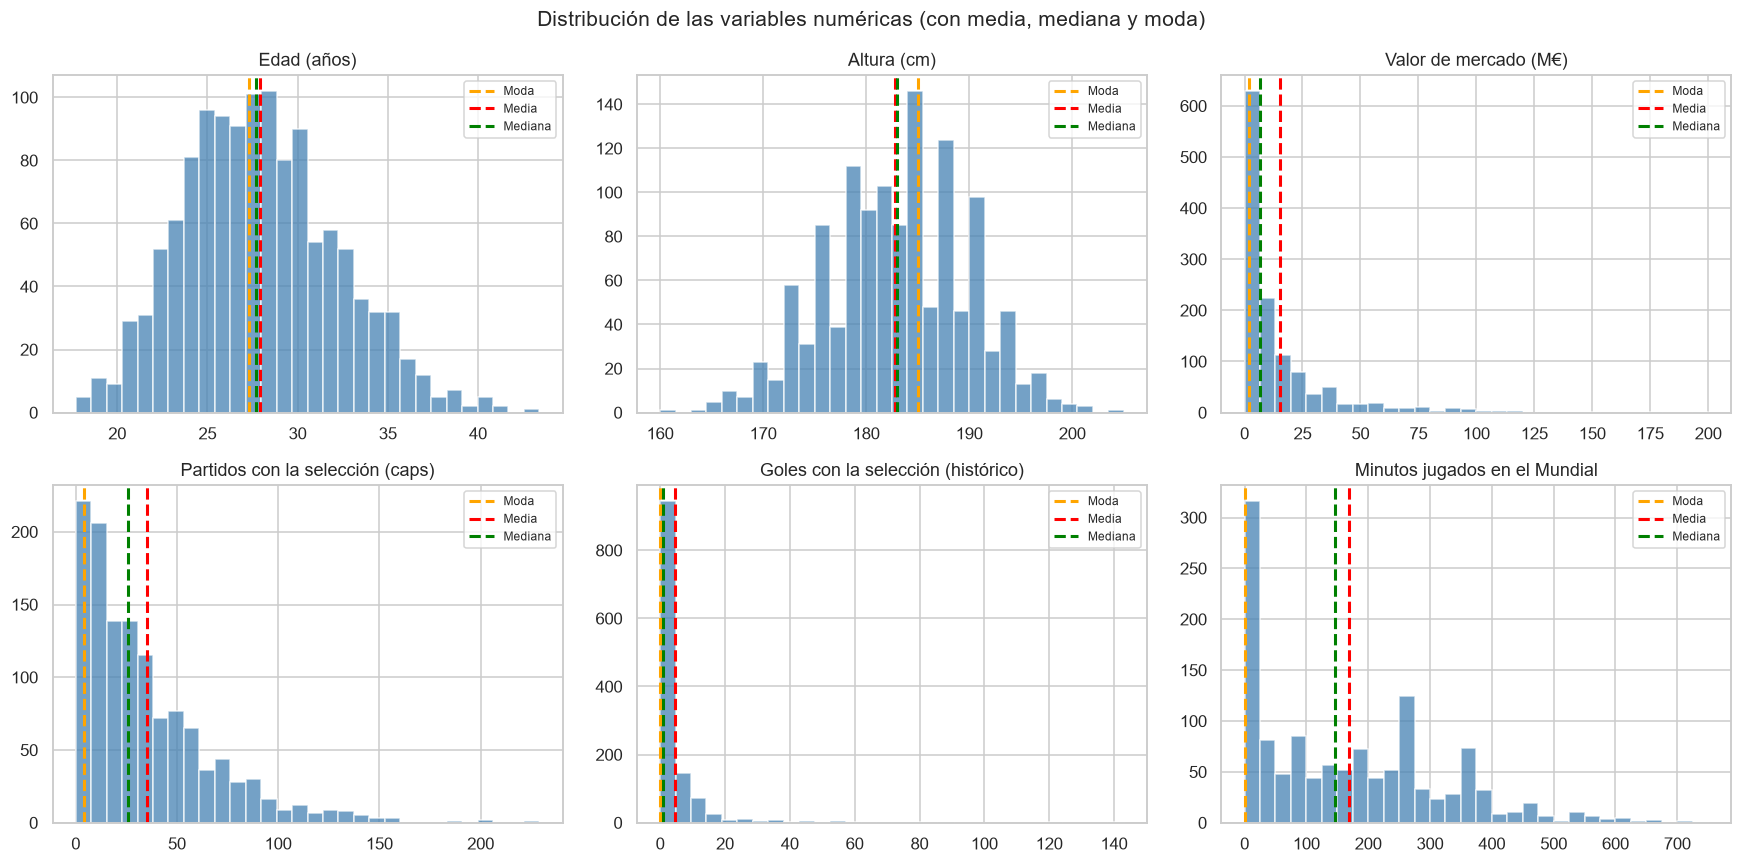

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

titulos = {
    'edad': 'Edad (años)',
    'height_cm': 'Altura (cm)',
    'valor_millones': 'Valor de mercado (M€)',
    'caps': 'Partidos con la selección (caps)',
    'goals': 'Goles con la selección (histórico)',
    'minutes_played': 'Minutos jugados en el Mundial',
}

for ax, col in zip(axes, principales):
    ax.hist(df[col], bins=30, alpha=0.75, color='steelblue')
    ax.axvline(df[col].mode()[0], color='orange', ls='--', lw=2, label='Moda')
    ax.axvline(df[col].mean(),    color='red',    ls='--', lw=2, label='Media')
    ax.axvline(df[col].median(),  color='green',  ls='--', lw=2, label='Mediana')
    ax.set_title(titulos[col])
    ax.legend(fontsize=8)

plt.suptitle('Distribución de las variables numéricas (con media, mediana y moda)', fontsize=14)
plt.tight_layout()
plt.show()

Se ven con claridad **dos familias de distribuciones**:

- **Simétricas / cuasi-normales:** `edad` y `height_cm`. Las tres líneas (moda, media, mediana) están casi superpuestas.
- **Muy asimétricas a la derecha:** `valor_millones`, `caps` y `goals`. La moda queda pegada al cero,
  la mediana un poco más a la derecha, y la media todavía más lejos, arrastrada por unos pocos valores enormes.
  El orden **moda < mediana < media** es exactamente el que la teoría describe para la asimetría positiva.

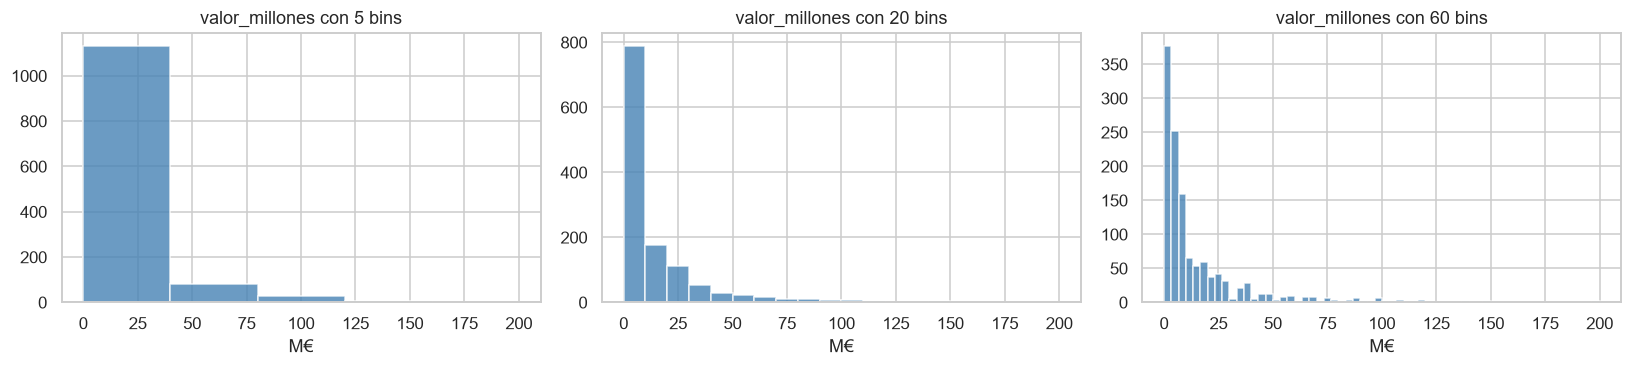

In [18]:
# Efecto de la cantidad de bins sobre la lectura del histograma
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for a, b in zip(ax, [5, 20, 60]):
    a.hist(df['valor_millones'], bins=b, color='steelblue', alpha=0.8)
    a.set_title(f'valor_millones con {b} bins')
    a.set_xlabel('M€')
plt.tight_layout()
plt.show()

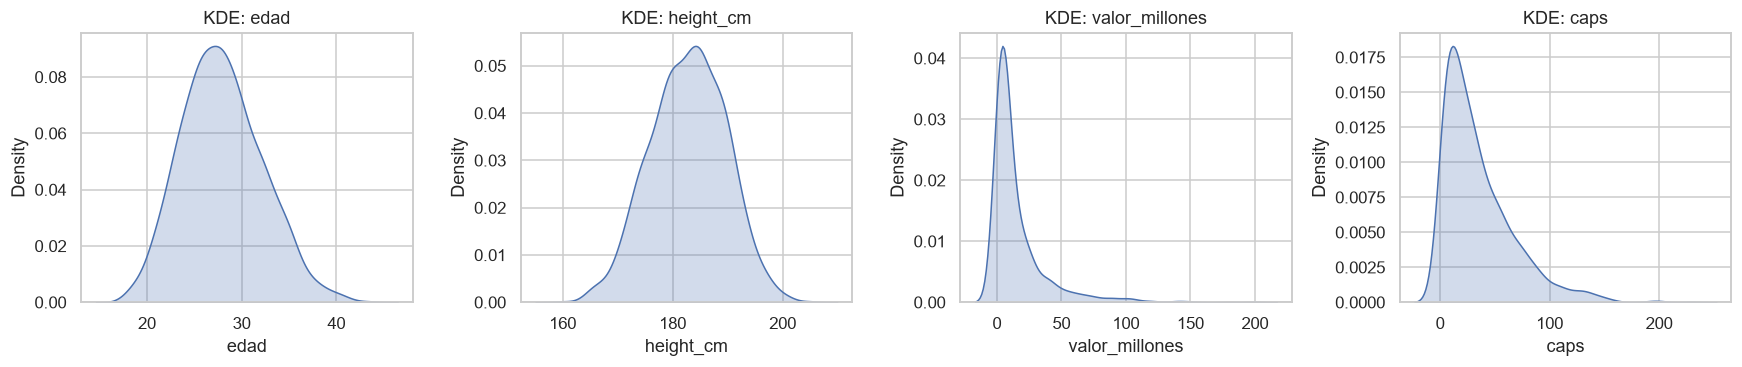

In [19]:
# KDE: estimación de la función de densidad de probabilidad
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, ['edad', 'height_cm', 'valor_millones', 'caps']):
    sns.kdeplot(data=df, x=col, fill=True, ax=ax)
    ax.set_title(f'KDE: {col}')
plt.tight_layout()
plt.show()

### 4.3. Medidas de dispersión: varianza y desviación estándar

In [20]:
dispersion = pd.DataFrame({
    'Media':           [df[c].mean() for c in principales],
    'Varianza':        [df[c].var()  for c in principales],
    'Desv. estándar':  [df[c].std()  for c in principales],
    'Rango':           [df[c].max() - df[c].min() for c in principales],
}, index=principales)

# Coeficiente de variación: dispersión relativa, comparable entre variables con distintas unidades
dispersion['Coef. variación'] = (dispersion['Desv. estándar'] / dispersion['Media']).round(3)
dispersion.round(2)

,Media,Varianza,Desv. estándar,Rango,Coef. variación
edad,27.94,18.16,4.26,25.70,0.15
height_cm,182.78,46.67,6.83,45.00,0.04
valor_millones,15.50,549.97,23.45,199.98,1.51
caps,34.99,"1,038.85",32.23,229.00,0.92
goals,4.52,108.10,10.40,143.00,2.30
minutes_played,169.00,"23,313.35",152.69,750.00,0.90


El **coeficiente de variación** (σ/μ) permite comparar dispersiones entre variables con unidades distintas:

- `height_cm` → **0,037**: la altura es la variable más homogénea, todos los jugadores miden más o menos lo mismo.
- `edad` → **0,153**: también bastante concentrada.
- `valor_millones` → **1,51**: el desvío es *una vez y media* la media. Es una variable extremadamente dispersa.

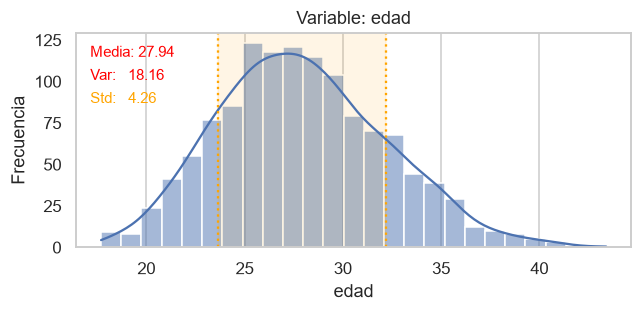

In [21]:
plot_histograma(df, 'edad', bins=25)

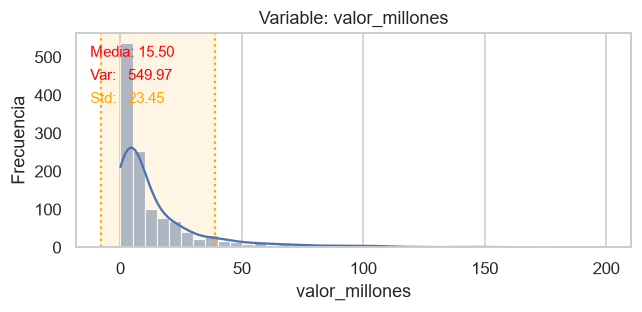

In [22]:
plot_histograma(df, 'valor_millones', bins=40)

En el histograma del valor de mercado, la banda ±1σ **se sale por la izquierda del rango posible de los datos**
(media − σ = 15,50 − 23,45 = −7,95 M€, y no existen valores negativos). Ese es un síntoma claro de que
la desviación estándar **no es una buena medida de dispersión** para esta variable: está inflada por los outliers.
Lo retomamos en la sección de estadística robusta (4.6).

### 4.4. Cuartiles y rango intercuartil (IQR)

In [23]:
v_Q1, v_Q2, v_Q3 = cuartiles(df['valor_millones'])
v_IQR = v_Q3 - v_Q1
rango_total = df['valor_millones'].max() - df['valor_millones'].min()

print('Variable: valor_millones (M€)')
print(f'  Q1 (25%)              : {v_Q1:.2f}')
print(f'  Q2 (mediana, 50%)     : {v_Q2:.2f}')
print(f'  Q3 (75%)              : {v_Q3:.2f}')
print(f'  IQR (Q3 - Q1)         : {v_IQR:.2f}')
print(f'  Rango total (max-min) : {rango_total:.2f}')
print(f'  IQR / rango total     : {100 * v_IQR / rango_total:.1f} %')

Variable: valor_millones (M€)
  Q1 (25%)              : 2.61
  Q2 (mediana, 50%)     : 6.57
  Q3 (75%)              : 18.00
  IQR (Q3 - Q1)         : 15.39
  Rango total (max-min) : 199.97
  IQR / rango total     : 7.7 %


Según el criterio visto en clase, **el IQR se considera pequeño si es menor al 20 % del rango total**.
Acá el IQR representa apenas el **7,7 %** del rango: la gran mayoría de los jugadores está **muy concentrada**
en valores bajos, y el rango total lo estira un puñado de estrellas.

In [24]:
# Cuartiles, IQR y outliers de todas las numéricas principales
filas = []
for c in principales:
    Q1, Q2, Q3 = cuartiles(df[c])
    IQR = Q3 - Q1
    li, ls = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    rango = df[c].max() - df[c].min()
    filas.append({
        'Variable': c, 'Q1': Q1, 'Mediana': Q2, 'Q3': Q3, 'IQR': IQR,
        'Lím. inf.': li, 'Lím. sup.': ls,
        'Outliers': int(((df[c] < li) | (df[c] > ls)).sum()),
        '% Outliers': round(100 * ((df[c] < li) | (df[c] > ls)).mean(), 1),
        'IQR/Rango (%)': round(100 * IQR / rango, 1),
    })
pd.DataFrame(filas).set_index('Variable').round(2)

,Q1,Mediana,Q3,IQR,Lím. inf.,Lím. sup.,Outliers,% Outliers,IQR/Rango (%)
Variable,,,,,,,,,
edad,25.00,27.70,30.60,5.60,16.60,39.00,10,0.80,21.80
height_cm,178.00,183.00,188.00,10.00,163.00,203.00,2,0.20,22.20
valor_millones,2.61,6.57,18.00,15.39,-20.48,41.09,113,9.10,7.70
caps,11.00,26.00,50.00,39.00,-47.50,108.50,48,3.80,17.00
goals,0.00,1.00,4.00,4.00,-6.00,10.00,133,10.70,2.80
minutes_played,23.00,146.00,270.00,247.00,-347.50,640.50,6,0.50,32.90


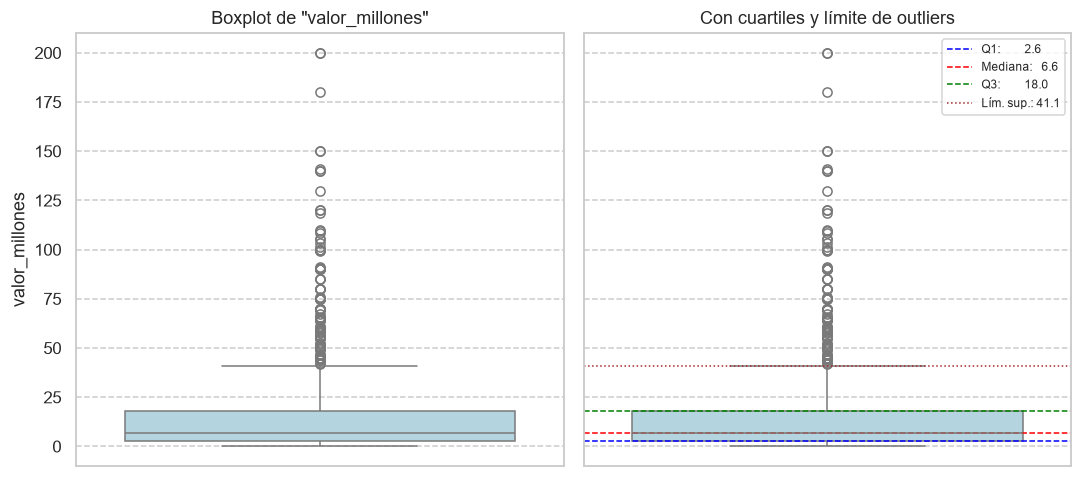

In [25]:
# Boxplot del valor de mercado: simple y con los cuartiles / límites de outliers marcados
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

lim_inf = v_Q1 - 1.5 * v_IQR
lim_sup = v_Q3 + 1.5 * v_IQR

sns.boxplot(data=df, y='valor_millones', color='lightblue', ax=ax[0])
ax[0].set_title('Boxplot de "valor_millones"')
ax[0].grid(axis='y', ls='--')

sns.boxplot(data=df, y='valor_millones', color='lightblue', ax=ax[1])
ax[1].axhline(v_Q1,    color='blue',   ls='--', lw=1, label=f'Q1:        {v_Q1:.1f}')
ax[1].axhline(v_Q2,    color='red',    ls='--', lw=1, label=f'Mediana:   {v_Q2:.1f}')
ax[1].axhline(v_Q3,    color='green',  ls='--', lw=1, label=f'Q3:        {v_Q3:.1f}')
ax[1].axhline(lim_sup, color='brown',  ls=':',  lw=1, label=f'Lím. sup.: {lim_sup:.1f}')
ax[1].set_title('Con cuartiles y límite de outliers')
ax[1].legend(fontsize=8)
ax[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

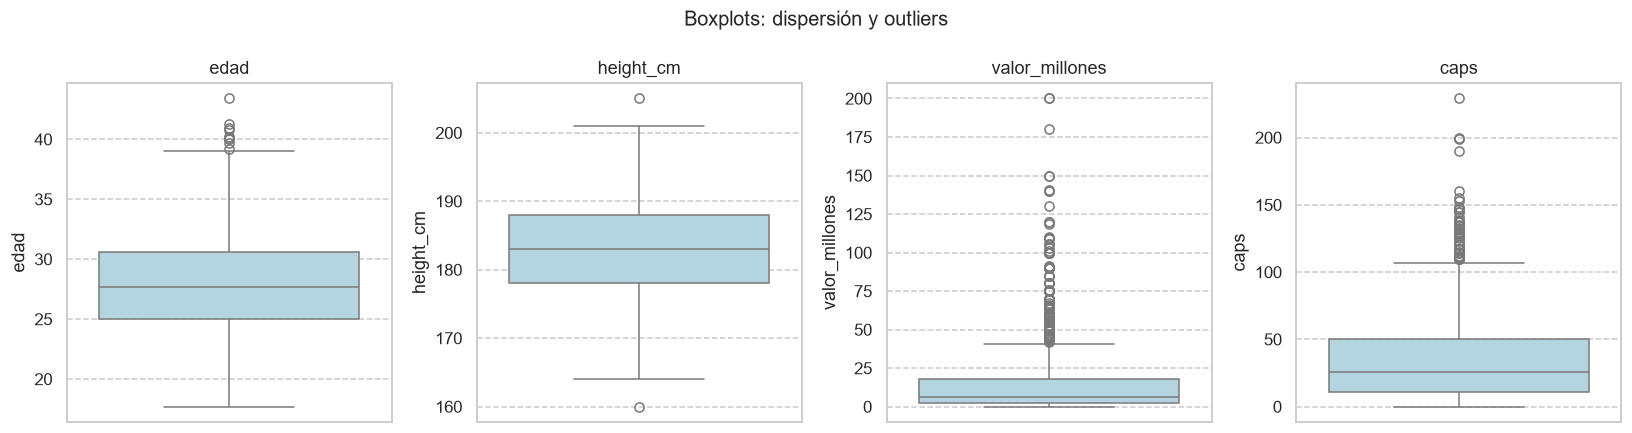

In [26]:
# Boxplots de las variables numéricas principales
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, ['edad', 'height_cm', 'valor_millones', 'caps']):
    sns.boxplot(data=df, y=col, color='lightblue', ax=ax)
    ax.set_title(col)
    ax.grid(axis='y', ls='--')
plt.suptitle('Boxplots: dispersión y outliers', fontsize=13)
plt.tight_layout()
plt.show()

`edad` y `height_cm` casi no tienen outliers (10 y 2 respectivamente, todos casos reales y plausibles:
el arquero más alto mide **205 cm** y el jugador más joven tiene **17,7 años**).
`valor_millones` tiene **113 outliers (9,1 %)** por el criterio de 1,5·IQR — pero **no son errores de datos**:
son las estrellas del torneo. Es un buen ejemplo de que "outlier estadístico" no significa "dato malo".

### 4.5. Medidas de forma: asimetría (skewness) y curtosis

In [27]:
forma = pd.DataFrame({
    'Asimetría (Pandas)': [df[c].skew() for c in principales],
    'Asimetría (SciPy)':  [st.skew(df[c]) for c in principales],
    'Curtosis exceso (Pandas)': [df[c].kurt() for c in principales],
    'Curtosis exceso (SciPy)':  [st.kurtosis(df[c]) for c in principales],
}, index=principales)
forma.round(3)

,Asimetría (Pandas),Asimetría (SciPy),Curtosis exceso (Pandas),Curtosis exceso (SciPy)
edad,0.33,0.33,-0.10,-0.11
height_cm,-0.09,-0.09,-0.26,-0.26
valor_millones,3.26,3.26,14.20,14.14
caps,1.61,1.61,3.40,3.38
goals,5.98,5.97,51.57,51.36
minutes_played,0.76,0.76,0.05,0.05


**Interpretación:**

| Variable | Asimetría | Curtosis exceso | Lectura |
|---|---|---|---|
| `height_cm` | −0,09 | −0,26 | Prácticamente **simétrica** y levemente **platicúrtica** (colas finas). Casi normal. |
| `edad` | +0,33 | −0,10 | Leve asimetría positiva; forma muy cercana a la normal. |
| `minutes_played` | +0,76 | +0,05 | Asimetría positiva moderada. |
| `caps` | +1,61 | +3,40 | **Fuerte asimetría positiva** y **leptocúrtica**: pocos jugadores con muchísimos partidos. |
| `valor_millones` | +3,26 | +14,20 | Asimetría positiva **muy fuerte** y curtosis altísima: colas pesadas, muchos valores extremos. |
| `goals` | +5,98 | +51,57 | El caso más extremo: la mayoría tiene 0 goles y unos pocos tienen decenas. |

Recordando la teoría: curtosis **exceso > 0** ⇒ leptocúrtica (más concentración en el centro y colas más pesadas
que la normal); **< 0** ⇒ platicúrtica.

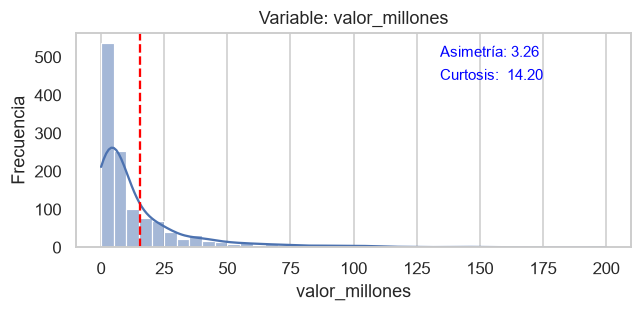

In [28]:
plot_histograma(df, 'valor_millones', bins=40, mvd=False, snk=True)

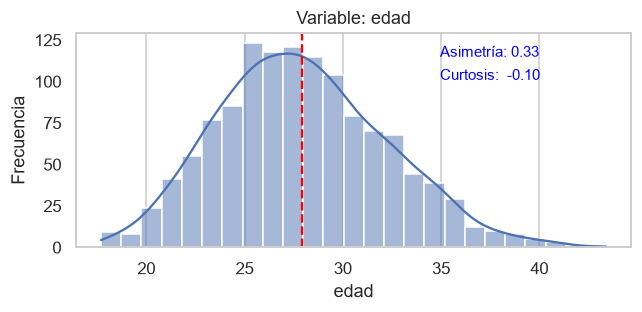

In [29]:
plot_histograma(df, 'edad', bins=25, mvd=False, snk=True)

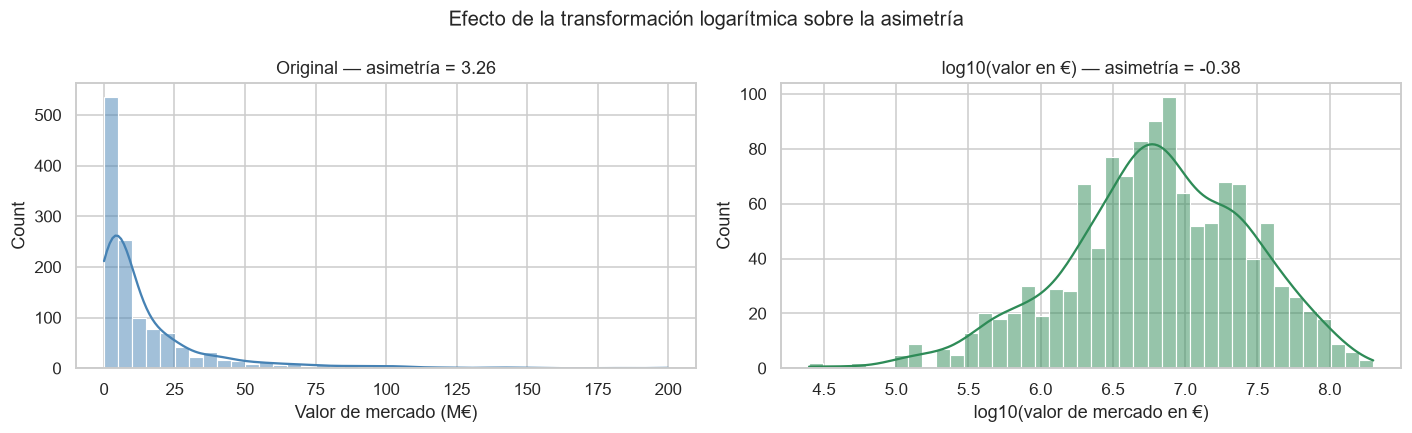

In [30]:
# La transformación logarítmica "endereza" una distribución con cola derecha larga
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['valor_millones'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Original — asimetría = {df['valor_millones'].skew():.2f}")
axes[0].set_xlabel('Valor de mercado (M€)')

log_valor = np.log10(df['market_value_eur'])
sns.histplot(log_valor, bins=40, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'log10(valor en €) — asimetría = {log_valor.skew():.2f}')
axes[1].set_xlabel('log10(valor de mercado en €)')

plt.suptitle('Efecto de la transformación logarítmica sobre la asimetría', fontsize=13)
plt.tight_layout()
plt.show()

Al pasar a escala logarítmica, la asimetría cae de **+3,26** a **−0,38** y la distribución se vuelve
razonablemente simétrica. Esto sugiere que el valor de mercado se comporta de forma aproximadamente
**log-normal**, algo habitual en variables económicas.

### 4.6. Estadística robusta

Las medidas clásicas (media, varianza, desvío) son **sensibles a los outliers**. La estadística robusta
propone alternativas que "capturan la información sin verse afectadas por valores extremos":

- Tendencia central robusta: **mediana** y **media recortada** (*trimmed mean*).
- Dispersión robusta: **IQR** y **MAD** (*Median Absolute Deviation*).

In [31]:
def comparacion_robusta(data, columnas, trim=0.10):
    filas = []
    for c in columnas:
        x = data[c].dropna()
        filas.append({
            'Variable': c,
            'Media': x.mean(),
            'Media recortada 10%': st.trim_mean(x, trim),
            'Mediana': x.median(),
            'Desv. estándar': x.std(),
            'IQR': x.quantile(0.75) - x.quantile(0.25),
            'MAD': st.median_abs_deviation(x),
            'Std / MAD': x.std() / st.median_abs_deviation(x) if st.median_abs_deviation(x) else np.nan,
        })
    return pd.DataFrame(filas).set_index('Variable')

comparacion_robusta(df, ['edad', 'height_cm', 'valor_millones', 'caps']).round(2)

,Media,Media recortada 10%,Mediana,Desv. estándar,IQR,MAD,Std / MAD
Variable,,,,,,,
edad,27.94,27.79,27.70,4.26,5.60,2.80,1.52
height_cm,182.78,182.85,183.00,6.83,10.00,5.00,1.37
valor_millones,15.50,10.24,6.57,23.45,15.39,5.07,4.62
caps,34.99,30.03,26.00,32.23,39.00,18.00,1.79


**Lectura clave:**

- En `edad` y `height_cm` las medidas clásicas y las robustas **casi no se diferencian**
  (media 27,94 vs. media recortada 27,79 vs. mediana 27,70). Cuando la distribución es simétrica y sin outliers,
  da lo mismo cuál usar.
- En `valor_millones` la diferencia es enorme: media **15,50**, media recortada 10 % **10,24**, mediana **6,57**.
  Y la dispersión: desvío estándar **23,45** contra MAD **5,07** — la razón `Std/MAD` es **4,6**.
  Ese cociente es en sí mismo un indicador de cuánto están distorsionando los outliers a la medida clásica.

**Conclusión:** para describir el valor de mercado de los jugadores hay que usar **mediana + IQR**, no media + desvío.

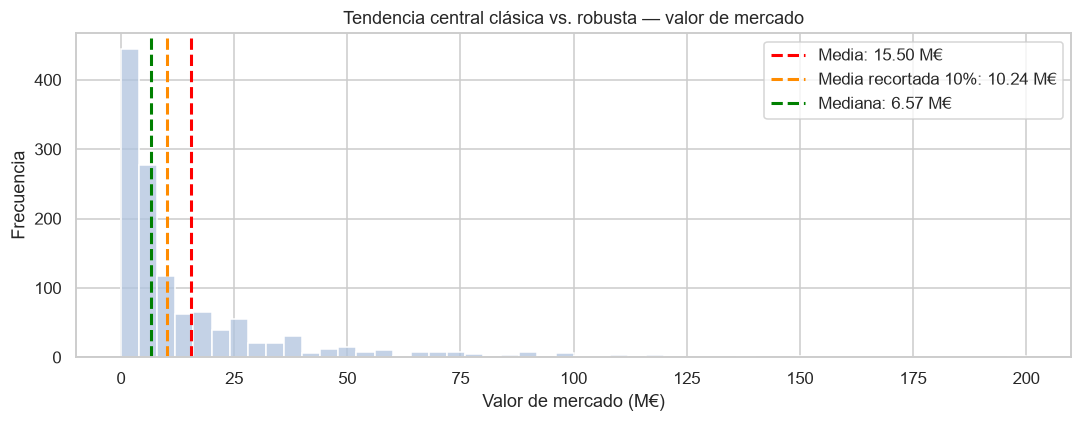

In [32]:
# Visualizamos las tres medidas de tendencia central sobre el histograma del valor
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['valor_millones'], bins=50, color='lightsteelblue', ax=ax)

ax.axvline(df['valor_millones'].mean(), color='red', ls='--', lw=2,
           label=f"Media: {df['valor_millones'].mean():.2f} M€")
ax.axvline(st.trim_mean(df['valor_millones'], 0.10), color='darkorange', ls='--', lw=2,
           label=f"Media recortada 10%: {st.trim_mean(df['valor_millones'], 0.10):.2f} M€")
ax.axvline(df['valor_millones'].median(), color='green', ls='--', lw=2,
           label=f"Mediana: {df['valor_millones'].median():.2f} M€")

ax.set_title('Tendencia central clásica vs. robusta — valor de mercado')
ax.set_xlabel('Valor de mercado (M€)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico deja ver el problema con claridad: **la media (roja) queda a la derecha del grueso de los datos**,
en una zona donde casi no hay jugadores. La mediana (verde) sí cae donde está la masa de la distribución.
La media recortada queda en el medio, como corresponde a una medida intermedia.

### 4.7. Estadística descriptiva completa

In [33]:
df[principales + ['elo_rating', 'fifa_ranking_pre_tournament']].describe().round(2)

,edad,height_cm,valor_millones,caps,goals,minutes_played,elo_rating,fifa_ranking_pre_tournament
count,"1,248.00","1,248.00","1,248.00","1,248.00","1,248.00","1,248.00","1,248.00","1,248.00"
mean,27.94,182.78,15.50,34.99,4.52,169.00,"1,801.56",32.69
std,4.26,6.83,23.45,32.23,10.40,152.69,159.24,23.27
min,17.70,160.00,0.02,0.00,0.00,0.00,"1,510.00",1.00
25%,25.00,178.00,2.61,11.00,0.00,23.00,"1,677.50",13.75
50%,27.70,183.00,6.57,26.00,1.00,146.00,"1,792.50",26.50
75%,30.60,188.00,18.00,50.00,4.00,270.00,"1,925.00",51.00
max,43.40,205.00,200.00,229.00,143.00,750.00,"2,150.00",85.00


In [34]:
# describe() con percentiles adicionales, para ver mejor las colas
df[['valor_millones', 'caps', 'goals']].describe(percentiles=[.05, .10, .25, .50, .75, .90, .95, .99]).round(2)

,valor_millones,caps,goals
count,"1,248.00","1,248.00","1,248.00"
mean,15.50,34.99,4.52
std,23.45,32.23,10.40
min,0.02,0.00,0.00
5%,0.45,2.00,0.00
10%,0.89,4.00,0.00
25%,2.61,11.00,0.00
50%,6.57,26.00,1.00
75%,18.00,50.00,4.00
90%,40.00,77.30,11.00


Los percentiles muestran la concentración con crudeza: el **percentil 95** del valor de mercado es de **62,7 M€**,
pero el máximo es **200 M€**. Es decir, el 5 % más caro se reparte un rango de 135 M€.
De hecho, **el 10 % de los jugadores más caros concentra el 46,8 % del valor total de todos los planteles**.

In [35]:
# Verificamos esa concentración
v = df['valor_millones'].sort_values(ascending=False)
top10 = int(len(v) * 0.10)
print(f'Jugadores totales                    : {len(v)}')
print(f'10% más caro (n)                     : {top10}')
print(f'Valor total de todos los planteles   : {v.sum():,.0f} M€')
print(f'Valor acumulado por el 10% más caro  : {v.head(top10).sum():,.0f} M€')
print(f'Porcentaje del total                 : {100 * v.head(top10).sum() / v.sum():.1f} %')

Jugadores totales                    : 1248
10% más caro (n)                     : 124
Valor total de todos los planteles   : 19,343 M€
Valor acumulado por el 10% más caro  : 9,045 M€
Porcentaje del total                 : 46.8 %


In [36]:
# Estadística descriptiva con SciPy
cols_sp = ['edad', 'height_cm', 'valor_millones', 'caps']
ed = st.describe(df[cols_sp].to_numpy())

pd.DataFrame({
    'Observaciones': ed.nobs,
    'Mín': ed.minmax[0],
    'Máx': ed.minmax[1],
    'Media': ed.mean,
    'Varianza': ed.variance,
    'Asimetría': ed.skewness,
    'Curtosis': ed.kurtosis,
}, index=cols_sp).round(3)

,Observaciones,Mín,Máx,Media,Varianza,Asimetría,Curtosis
edad,1248,17.70,43.40,27.93,18.16,0.33,-0.11
height_cm,1248,160.00,205.00,182.78,46.67,-0.09,-0.26
valor_millones,1248,0.03,200.00,15.50,549.97,3.26,14.14
caps,1248,0.00,229.00,34.99,"1,038.85",1.61,3.38


---
## 5. Exploración de VARIABLES CATEGÓRICAS

Las variables categóricas se describen a partir de **cantidades, proporciones y porcentajes** de sus categorías.

### 5.1. Frecuencias absolutas y relativas

In [37]:
print_categorias(df, 'position')

Cantidad de categorías de 'position': 4

Categorías presentes: ['GK', 'DEF', 'MID', 'FWD']

Frecuencias de 'position':
          Frecuencia absoluta  Frecuencia relativa (%)
position                                              
DEF                       421                    33.73
MID                       369                    29.57
FWD                       313                    25.08
GK                        145                    11.62



In [38]:
print_categorias(df, 'confederation')

Cantidad de categorías de 'confederation': 6

Categorías presentes: ['CONCACAF', 'CAF', 'AFC', 'UEFA', 'CONMEBOL', 'OFC']

Frecuencias de 'confederation':
               Frecuencia absoluta  Frecuencia relativa (%)
confederation                                              
UEFA                           416                    33.33
CAF                            260                    20.83
AFC                            234                    18.75
CONCACAF                       156                    12.50
CONMEBOL                       156                    12.50
OFC                             26                     2.08



In [39]:
print_categorias(df, 'nivel_elo')

Cantidad de categorías de 'nivel_elo': 4

Categorías presentes: ['Alto', 'Bajo', 'Medio', 'Élite']

Frecuencias de 'nivel_elo':
           Frecuencia absoluta  Frecuencia relativa (%)
nivel_elo                                              
Bajo                       312                    25.00
Medio                      312                    25.00
Alto                       312                    25.00
Élite                      312                    25.00



In [40]:
print_categorias(df, 'club_team', max_cat=10)

Cantidad de categorías de 'club_team': 450

(Alta cardinalidad, se muestran las 10 más frecuentes)

Frecuencias de 'club_team':
                      Frecuencia absoluta  Frecuencia relativa (%)
club_team                                                         
Manchester City FC                     19                     1.52
FC Bayern München                      17                     1.36
Paris Saint-Germain                    16                     1.28
Arsenal FC                             15                     1.20
FC Barcelona                           15                     1.20
Crystal Palace FC                      12                     0.96
Atlético De Madrid                     12                     0.96
Al Hilal SC                            12                     0.96
Manchester United FC                   12                     0.96
Borussia Dortmund                      11                     0.88



### 5.2. Descripción de categóricas con `describe()`

In [41]:
df.describe(include='category')

# count  = cantidad de datos no nulos
# unique = cantidad de categorías distintas (cardinalidad)
# top    = categoría más frecuente (moda)
# freq   = frecuencia de la categoría top

,position,club_team,team_name,fifa_code,group_letter,confederation,franja_etaria,nivel_elo
count,1248,1248,1248,1248,1248,1248,1248,1248
unique,4,450,48,48,12,6,3,4
top,DEF,Manchester City FC,Algeria,ALG,A,UEFA,23-29,Bajo
freq,421,19,26,26,104,416,620,312


### 5.3. Concentración, diversidad y entropía de Shannon

Aplicamos las métricas de la teoría: **cardinalidad**, **proporción de la moda**, **rango de frecuencias**
y **entropía de Shannon** (con su valor máximo teórico log₂(n) y la versión normalizada H/H_máx).

In [42]:
resumen_categoricas(df, ['position', 'confederation', 'group_letter',
                         'franja_etaria', 'nivel_elo', 'team_name'])

,Cardinalidad,Moda,Frec. moda,Prop. moda,Rango de frecuencias,Entropía (bits),Entropía máx.,Entropía norm.
Variable,,,,,,,,
position,4,DEF,421,0.34,276,1.91,2.00,0.95
confederation,6,UEFA,416,0.33,390,2.32,2.58,0.90
group_letter,12,A,104,0.08,0,3.58,3.58,1.00
franja_etaria,3,23-29,620,0.50,464,1.41,1.58,0.89
nivel_elo,4,Bajo,312,0.25,0,2.00,2.00,1.00
team_name,48,Algeria,26,0.02,0,5.58,5.58,1.00


**Interpretación de la entropía:**

- **`group_letter` → H = 3,585 bits = H_máx (entropía normalizada = 1,000).** Es el caso de **entropía máxima**:
  las 12 categorías son *exactamente* igual de probables (104 jugadores en cada grupo). No es casualidad,
  es el diseño del torneo: 4 selecciones por grupo × 26 jugadores. Conocer el grupo de un jugador no reduce
  para nada la incertidumbre — es la variable **menos informativa** del dataset.
- **`nivel_elo` → normalizada = 1,000** también, pero por construcción: los cuartiles reparten 312 jugadores en cada nivel.
- **`position` → H = 1,910 sobre un máximo de 2,000 (0,955).** Bastante uniforme, aunque no del todo:
  hay 421 defensores contra apenas 145 arqueros. La distribución refleja la lógica del fútbol
  (cada selección lleva 3 arqueros de 26 convocados = 11,5 %).
- **`confederation` → H = 2,319 sobre 2,585 (0,897).** Es la más **desbalanceada** de las tres:
  UEFA aporta 416 jugadores (33,3 %) mientras que OFC aporta solo 26 (2,1 %). El rango de frecuencias es de **390**.

Cuanto más baja la entropía normalizada, más dominada está la variable por unas pocas categorías.

### 5.4. Visualizaciones de variables categóricas

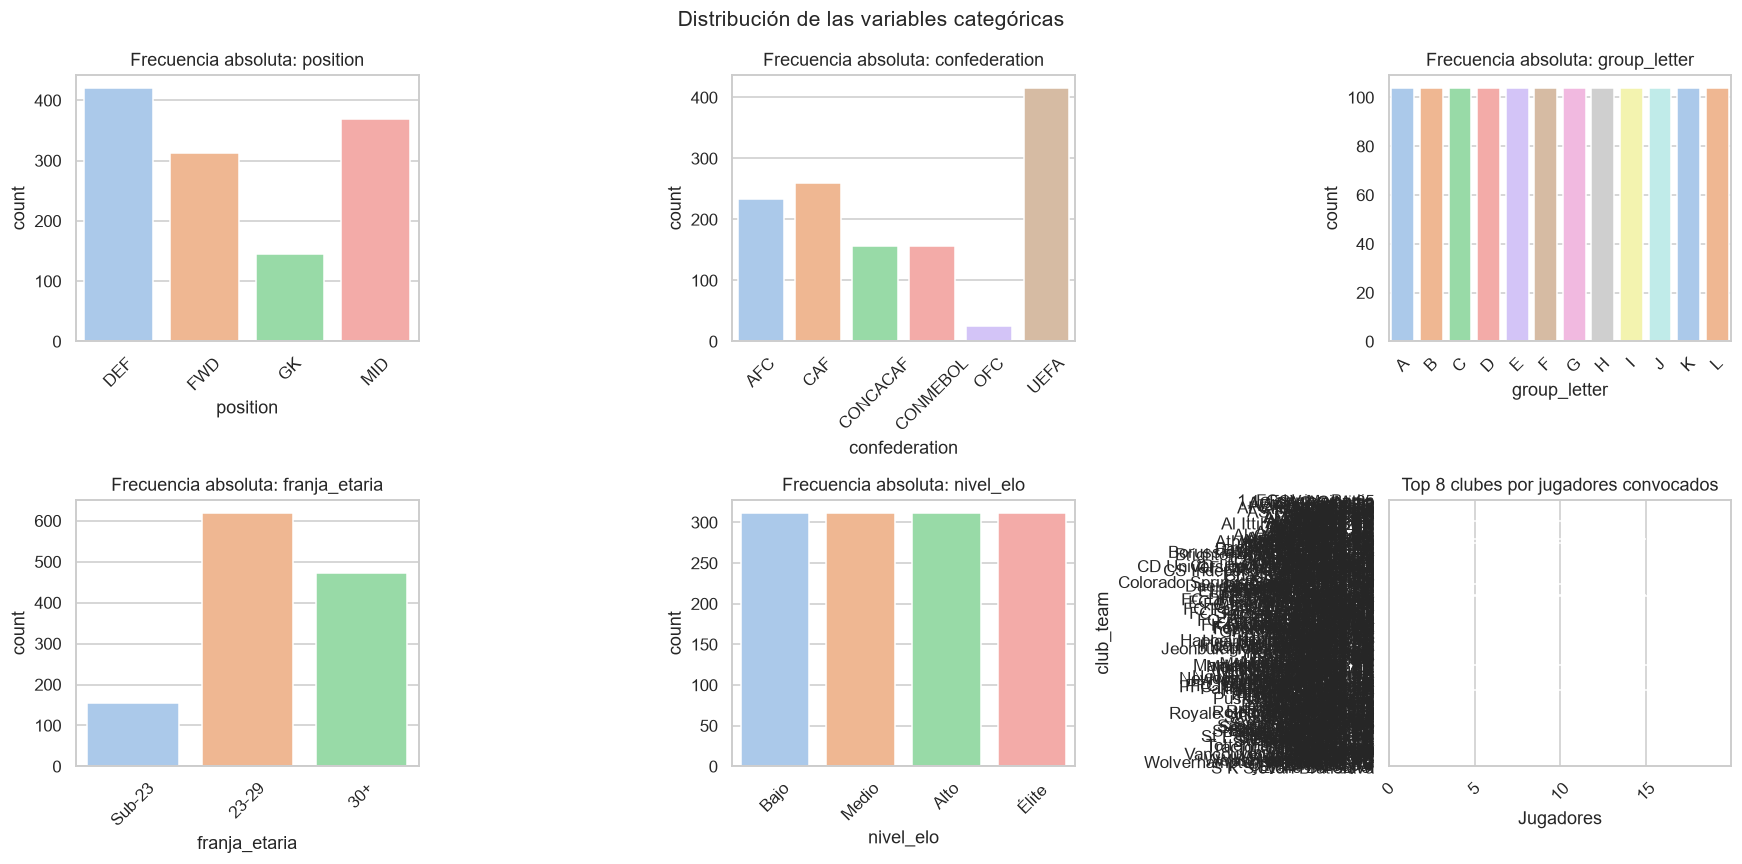

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, ['position', 'confederation', 'group_letter',
                          'franja_etaria', 'nivel_elo', 'position']):
    sns.countplot(x=col, data=df, hue=col, palette='pastel', ax=ax, legend=False)
    ax.set_title(f'Frecuencia absoluta: {col}')
    ax.tick_params(axis='x', rotation=45)

# El último panel: top 8 clubes (alta cardinalidad, mostramos solo los más frecuentes)
axes[5].clear()
top_clubes = df['club_team'].value_counts().head(8)
sns.barplot(x=top_clubes.values, y=top_clubes.index, hue=top_clubes.index,
            palette='viridis', ax=axes[5], legend=False)
axes[5].set_title('Top 8 clubes por jugadores convocados')
axes[5].set_xlabel('Jugadores')

plt.suptitle('Distribución de las variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

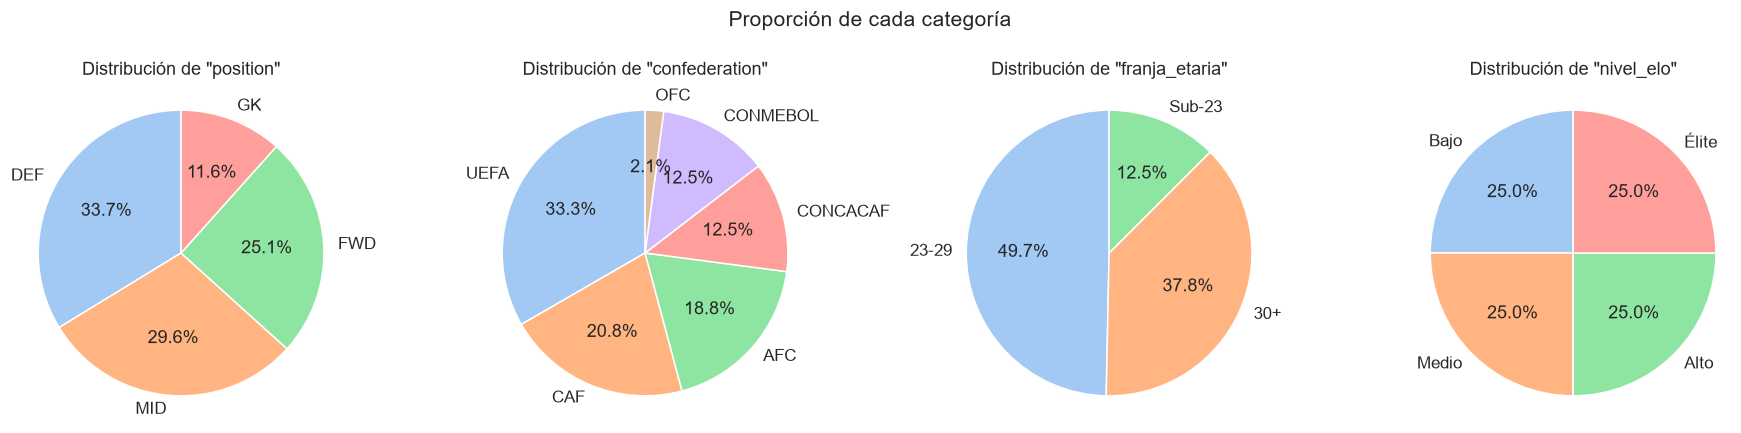

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['position', 'confederation', 'franja_etaria', 'nivel_elo']):
    plot_pie(df, col, ax=ax)
plt.suptitle('Proporción de cada categoría', fontsize=14)
plt.tight_layout()
plt.show()

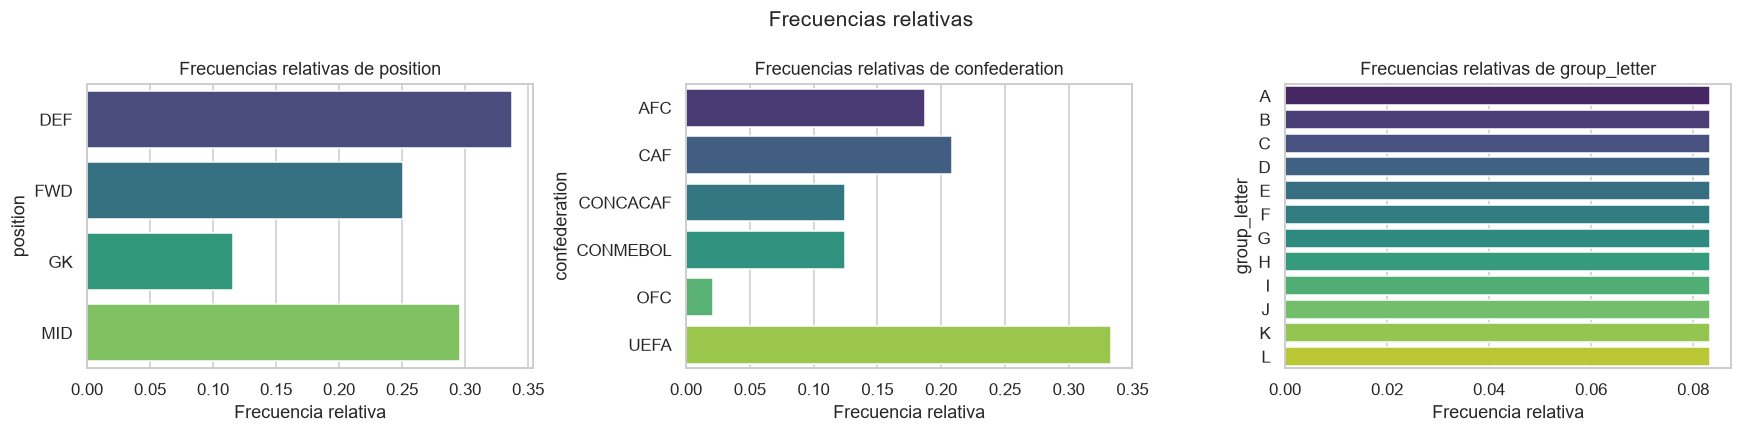

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['position', 'confederation', 'group_letter']):
    plot_frecuencias_relativas(df, col, ax=ax)
plt.suptitle('Frecuencias relativas', fontsize=14)
plt.tight_layout()
plt.show()

El gráfico de `group_letter` es la imagen visual de la **entropía máxima**: doce barras exactamente iguales.
El de `confederation`, en cambio, muestra el desbalance del torneo (UEFA domina, OFC es marginal).

---
## 6. Relaciones entre variables

### 6.1. Numérica – numérica

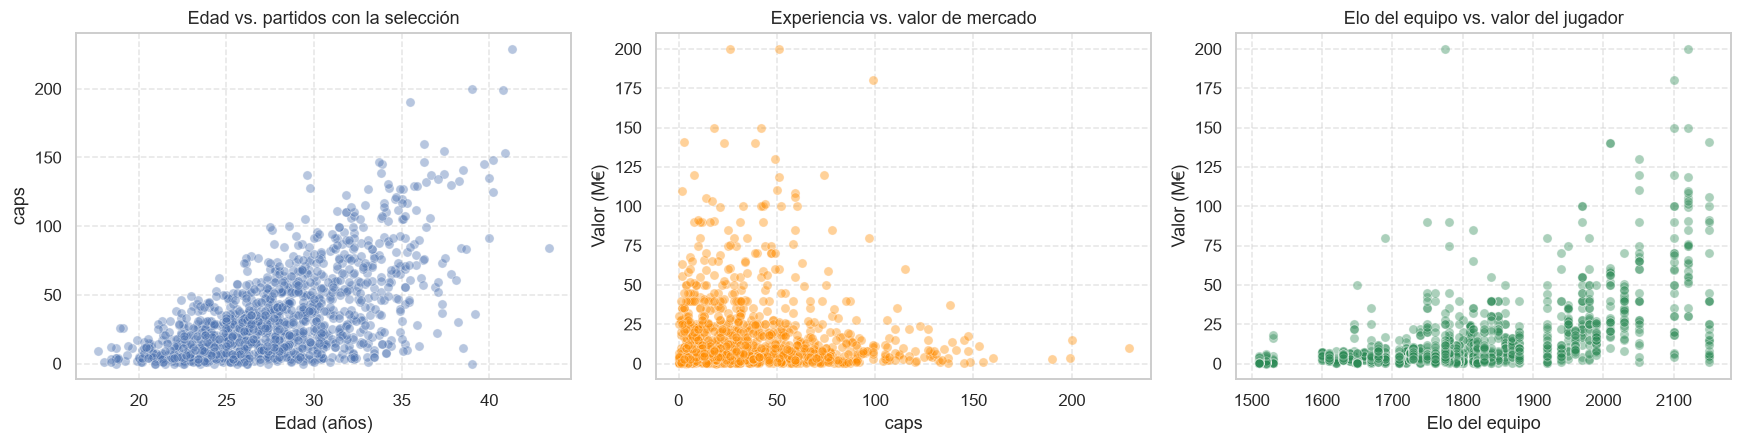

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.scatterplot(data=df, x='edad', y='caps', alpha=0.4, ax=axes[0])
axes[0].set_title('Edad vs. partidos con la selección')
axes[0].set_xlabel('Edad (años)'); axes[0].set_ylabel('caps')

sns.scatterplot(data=df, x='caps', y='valor_millones', alpha=0.4, color='darkorange', ax=axes[1])
axes[1].set_title('Experiencia vs. valor de mercado')
axes[1].set_xlabel('caps'); axes[1].set_ylabel('Valor (M€)')

sns.scatterplot(data=df, x='elo_rating', y='valor_millones', alpha=0.4, color='seagreen', ax=axes[2])
axes[2].set_title('Elo del equipo vs. valor del jugador')
axes[2].set_xlabel('Elo del equipo'); axes[2].set_ylabel('Valor (M€)')

for ax in axes:
    ax.grid(ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

En el tercer panel se ve claramente el efecto que advertimos al principio: como `elo_rating` es un atributo
del **equipo**, los puntos se agrupan en **columnas verticales** (una por selección, con sus 26 jugadores).

#### Covarianza y matriz de correlación

In [47]:
# La covarianza indica dirección, pero su magnitud depende de las unidades: es difícil de interpretar
print('Covarianza edad-caps         :', round(df['edad'].cov(df['caps']), 2))
print('Covarianza edad-valor(€)     :', round(df['edad'].cov(df['market_value_eur']), 2))
print('Covarianza edad-valor(M€)    :', round(df['edad'].cov(df['valor_millones']), 2))
print('\nLas dos últimas describen la MISMA relación, pero difieren en 6 órdenes de magnitud')
print('solo por el cambio de unidad. Por eso usamos la correlación, que es la covarianza escalada:')
print('\nCorrelación edad-valor(€)    :', round(df['edad'].corr(df['market_value_eur']), 4))
print('Correlación edad-valor(M€)   :', round(df['edad'].corr(df['valor_millones']), 4))

Covarianza edad-caps         : 84.21
Covarianza edad-valor(€)     : -22370038.31
Covarianza edad-valor(M€)    : -22.37

Las dos últimas describen la MISMA relación, pero difieren en 6 órdenes de magnitud
solo por el cambio de unidad. Por eso usamos la correlación, que es la covarianza escalada:

Correlación edad-valor(€)    : -0.2239
Correlación edad-valor(M€)   : -0.2239


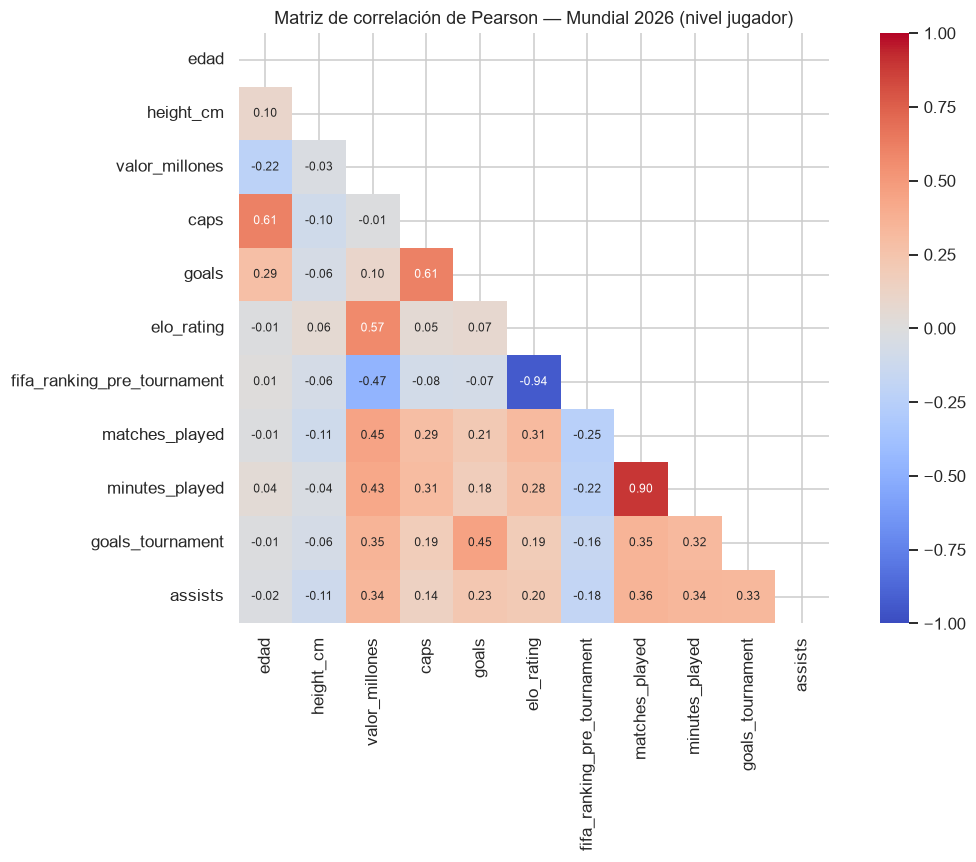

In [48]:
vars_corr = ['edad', 'height_cm', 'valor_millones', 'caps', 'goals',
             'elo_rating', 'fifa_ranking_pre_tournament',
             'matches_played', 'minutes_played', 'goals_tournament', 'assists']

corr_pearson = df[vars_corr].corr(method='pearson')

# Máscara para ocultar la mitad superior (información redundante: la matriz es simétrica)
mascara = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara,
            annot_kws={'size': 8})
plt.title('Matriz de correlación de Pearson — Mundial 2026 (nivel jugador)')
plt.tight_layout()
plt.show()

**Lecturas de la matriz:**

1. **`elo_rating` vs. `fifa_ranking_pre_tournament` = −0,94.** Correlación negativa casi perfecta, y tiene todo el
   sentido: un ranking FIFA *bajo* (posición 1, 2, 3…) significa un equipo *mejor*, o sea Elo alto. Son dos formas de
   medir lo mismo → **información redundante**. Si más adelante se armara un modelo predictivo, habría que quedarse
   con una sola de las dos para evitar multicolinealidad.
2. **`edad` vs. `caps` = 0,61** y **`caps` vs. `goals` = 0,61.** Relaciones moderadas y esperables: cuanto más viejo
   el jugador, más partidos acumuló; y cuantos más partidos, más goles.
3. **`caps` vs. `valor_millones` = −0,01.** ¡Prácticamente cero! La experiencia internacional **no explica**
   el valor de mercado. Es el hallazgo más contraintuitivo del análisis.
4. **`edad` vs. `valor_millones` = −0,22.** Correlación negativa: el mercado paga por **proyección**, no por trayectoria.
5. **`valor_millones` vs. `minutes_played` = 0,43** y **vs. `goals_tournament` = 0,35.** Los jugadores más caros
   efectivamente juegan más minutos y meten más goles en el torneo.

#### Comparación de los tres métodos de correlación

Pearson mide relación **lineal**; Spearman, relación **monótona** (sobre rangos); Kendall, la **proporción de pares
bien ordenados**. Compararlos permite detectar relaciones que Pearson no ve.

In [49]:
pares = [
    ('edad', 'caps'),
    ('caps', 'goals'),
    ('edad', 'valor_millones'),
    ('caps', 'valor_millones'),
    ('height_cm', 'goals'),
    ('elo_rating', 'valor_millones'),
    ('elo_rating', 'fifa_ranking_pre_tournament'),
    ('minutes_played', 'goals_tournament'),
    ('height_cm', 'edad'),
]

filas = []
for a, b in pares:
    p = df[a].corr(df[b], method='pearson')
    s = df[a].corr(df[b], method='spearman')
    k = df[a].corr(df[b], method='kendall')
    filas.append({'Par': f'{a} ~ {b}', 'Pearson': p, 'Spearman': s,
                  'Kendall': k, '|Spearman| - |Pearson|': abs(s) - abs(p)})

pd.DataFrame(filas).set_index('Par').round(3)

,Pearson,Spearman,Kendall,|Spearman| - |Pearson|
Par,,,,
edad ~ caps,0.61,0.56,0.41,-0.05
caps ~ goals,0.61,0.62,0.49,0.01
edad ~ valor_millones,-0.22,-0.24,-0.16,0.01
caps ~ valor_millones,-0.01,0.07,0.04,0.06
height_cm ~ goals,-0.06,-0.20,-0.15,0.15
elo_rating ~ valor_millones,0.57,0.65,0.47,0.07
elo_rating ~ fifa_ranking_pre_tournament,-0.94,-0.97,-0.86,0.04
minutes_played ~ goals_tournament,0.32,0.31,0.26,-0.01
height_cm ~ edad,0.10,0.10,0.07,0.00


**Dónde los métodos difieren (y por qué importa):**

- **`height_cm ~ goals`:** Pearson **−0,06** (parecería que no hay relación) pero Spearman **−0,20**.
  Spearman detecta una relación **monótona decreciente** que Pearson se pierde porque no es lineal:
  los jugadores más altos (arqueros y defensores) meten menos goles, pero la caída no sigue una recta.
  Es exactamente el caso que la teoría advierte como *"el problema de Pearson"*.
- **`elo_rating ~ valor_millones`:** Pearson **0,57** vs. Spearman **0,65**. De nuevo, la relación es monótona
  pero no lineal: el valor de los jugadores crece de forma **acelerada** con la calidad del equipo, no proporcional.
- **`caps ~ valor_millones`:** los tres coeficientes dan ~0 (−0,01 / 0,07 / 0,04). Cuando **los tres métodos coinciden
  en que no hay relación**, podemos afirmarlo con bastante confianza.
- **Kendall** siempre da valores más chicos que Spearman en magnitud: es normal, las dos escalas no son comparables
  directamente entre sí, aunque el orden y el signo sí coinciden.

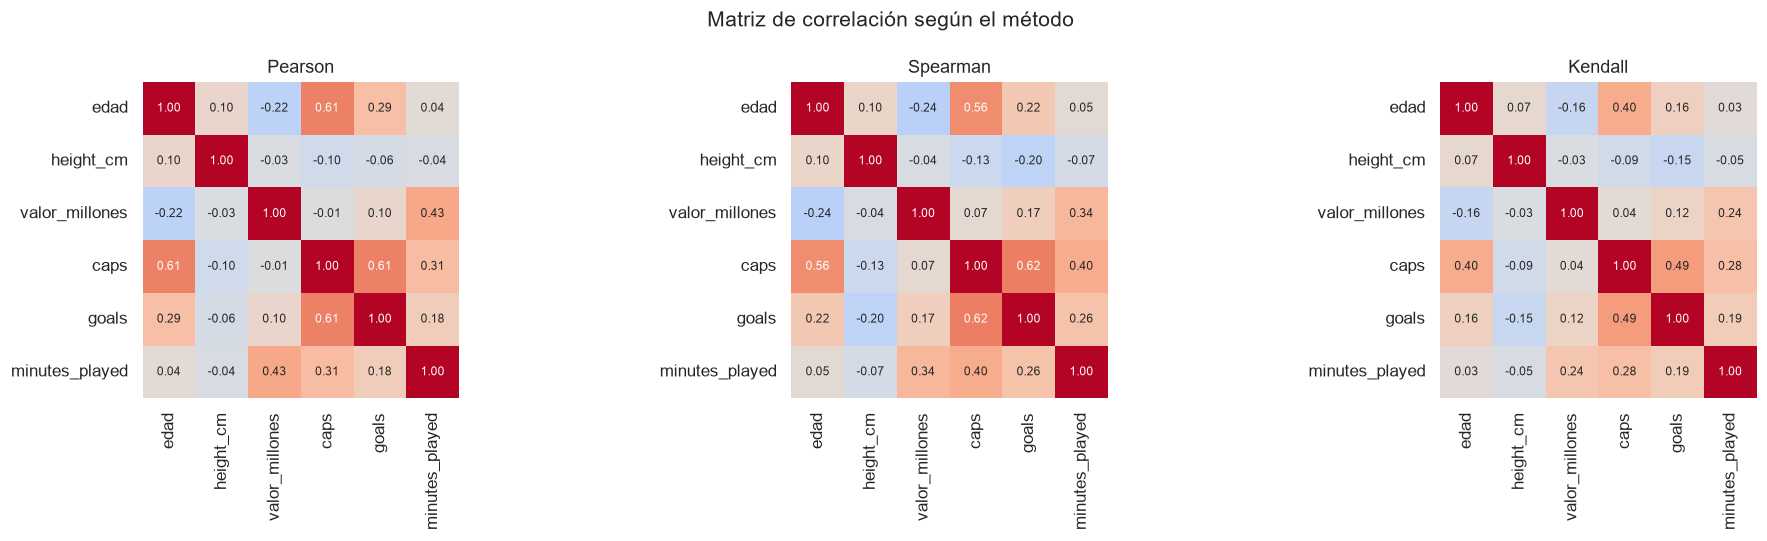

In [50]:
# Los tres métodos, lado a lado, sobre las variables principales
metodos = ['pearson', 'spearman', 'kendall']
vars_sel = ['edad', 'height_cm', 'valor_millones', 'caps', 'goals', 'minutes_played']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, metodos):
    cm = df[vars_sel].corr(method=m)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                center=0, square=True, cbar=False, ax=ax, annot_kws={'size': 8})
    ax.set_title(m.capitalize())
plt.suptitle('Matriz de correlación según el método', fontsize=14)
plt.tight_layout()
plt.show()

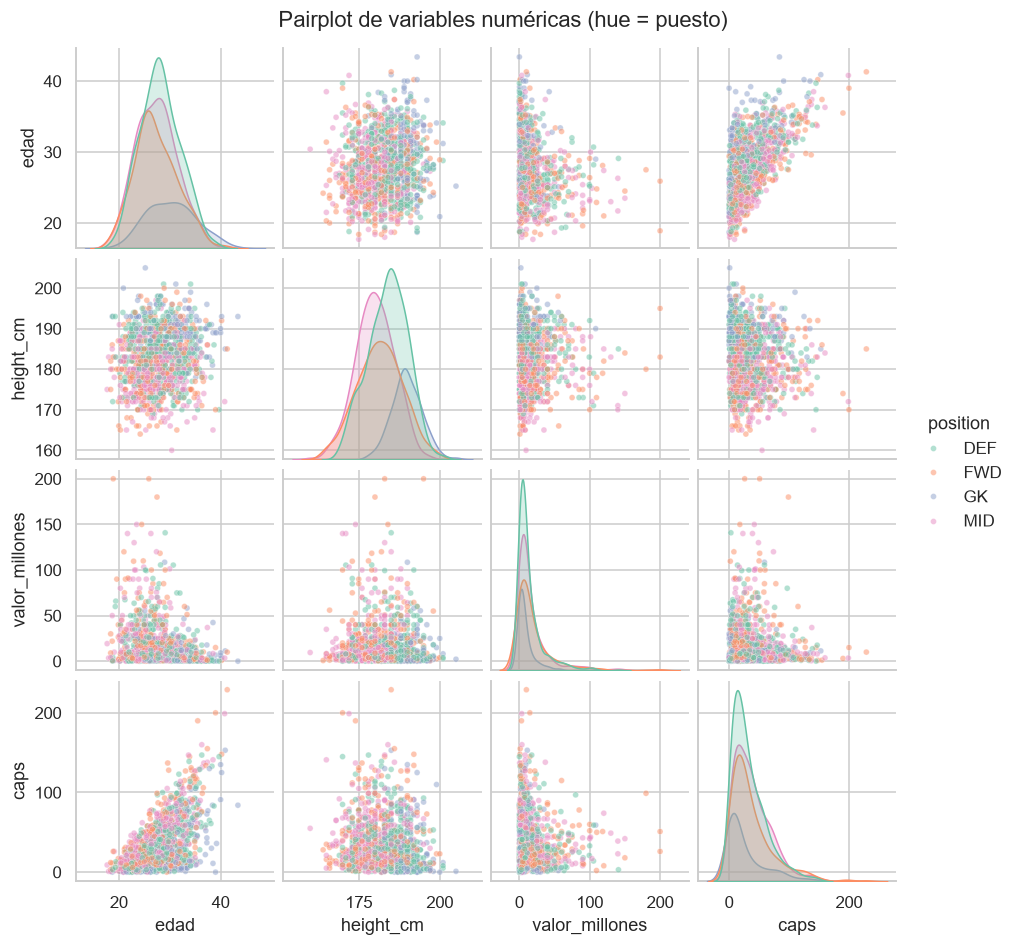

In [51]:
# Pairplot: scatterplots de las numéricas coloreados por una categórica
g = sns.pairplot(df[['edad', 'height_cm', 'valor_millones', 'caps', 'position']],
                 hue='position', palette='Set2', plot_kws={'alpha': 0.5, 's': 15},
                 diag_kind='kde', height=2.1)
g.figure.suptitle('Pairplot de variables numéricas (hue = puesto)', y=1.02)
plt.show()

El pairplot resume varias cosas de una sola vez. La más visible: en la diagonal, la **KDE de `height_cm`
separa nítidamente a los arqueros** (curva desplazada a la derecha) del resto de los puestos.

### 6.2. Categórica – categórica

In [52]:
tabla = pd.crosstab(df['confederation'], df['position'])
print('Tabla de contingencia (frecuencias absolutas):')
tabla

Tabla de contingencia (frecuencias absolutas):


position,DEF,FWD,GK,MID
confederation,,,,
AFC,84,54,27,69
CAF,87,67,31,75
CONCACAF,54,43,18,41
CONMEBOL,48,40,18,50
OFC,9,5,3,9
UEFA,139,104,48,125


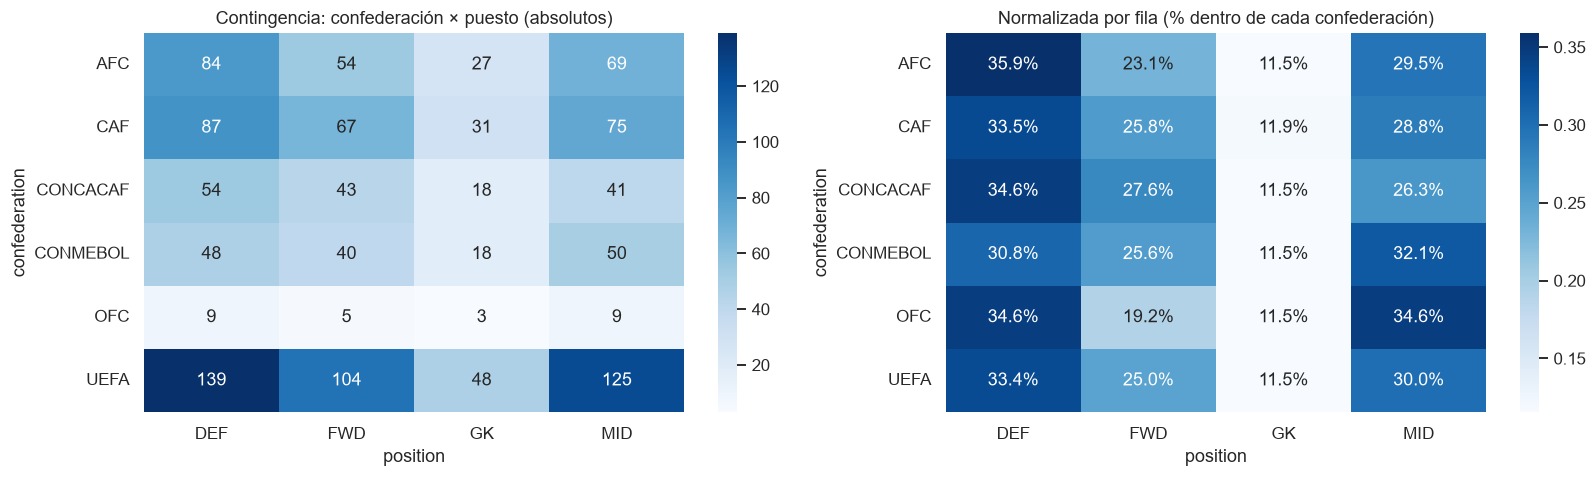

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Contingencia: confederación × puesto (absolutos)')

tabla_pct = pd.crosstab(df['confederation'], df['position'], normalize='index')
sns.heatmap(tabla_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_title('Normalizada por fila (% dentro de cada confederación)')

plt.tight_layout()
plt.show()

La tabla en absolutos solo repite lo que ya sabíamos (UEFA tiene más jugadores porque tiene más selecciones).
**La versión normalizada es la informativa**: muestra que la composición de los planteles es
**prácticamente idéntica en todas las confederaciones** (~33 % DEF, ~30 % MID, ~25 % FWD, **11,5 % GK exacto**).

Ese 11,5 % constante no es un hallazgo estadístico sino una **restricción del reglamento**: todas las selecciones
llevan 3 arqueros entre sus 26 convocados (3/26 = 11,5 %). Detectar estas relaciones *estructurales* —donde el dato
está determinado por una regla y no por un fenómeno— es parte del trabajo del EDA.

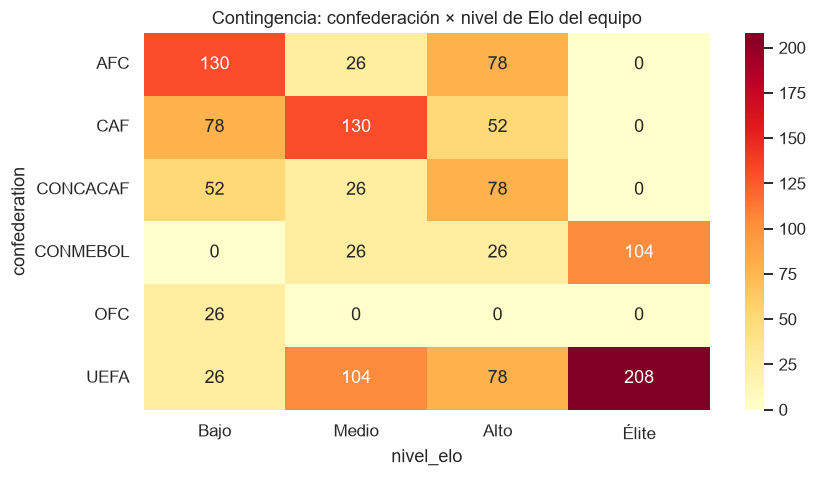

nivel_elo,Bajo,Medio,Alto,Élite
confederation,,,,
AFC,130,26,78,0
CAF,78,130,52,0
CONCACAF,52,26,78,0
CONMEBOL,0,26,26,104
OFC,26,0,0,0
UEFA,26,104,78,208


In [54]:
tabla_elo = pd.crosstab(df['confederation'], df['nivel_elo'])

plt.figure(figsize=(8, 4.5))
sns.heatmap(tabla_elo, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Contingencia: confederación × nivel de Elo del equipo')
plt.tight_layout()
plt.show()

tabla_elo

Acá sí aparece un patrón fuerte: **el nivel "Élite" está compuesto exclusivamente por UEFA (208 jugadores = 8 equipos)
y CONMEBOL (104 = 4 equipos)**. Ninguna selección de AFC, CAF, CONCACAF u OFC entra en el cuartil superior de Elo.
La jerarquía deportiva está claramente concentrada en dos confederaciones.

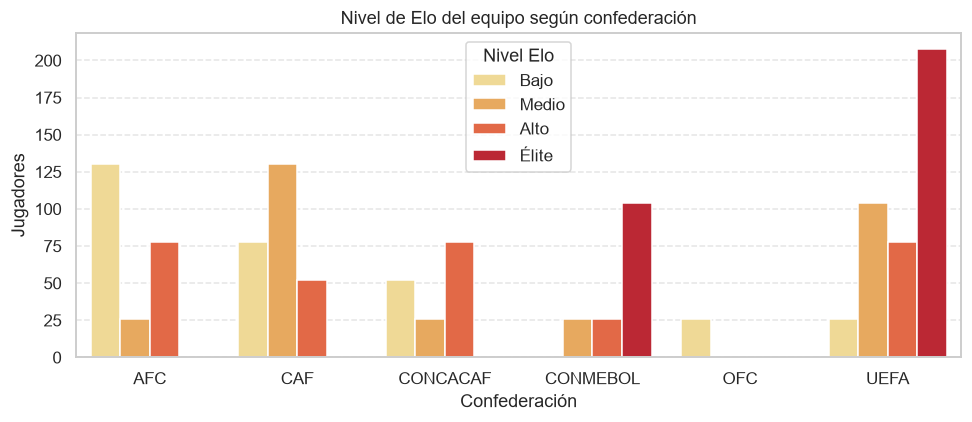

In [55]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='confederation', hue='nivel_elo', palette='YlOrRd')
plt.title('Nivel de Elo del equipo según confederación')
plt.xlabel('Confederación'); plt.ylabel('Jugadores')
plt.legend(title='Nivel Elo')
plt.grid(axis='y', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

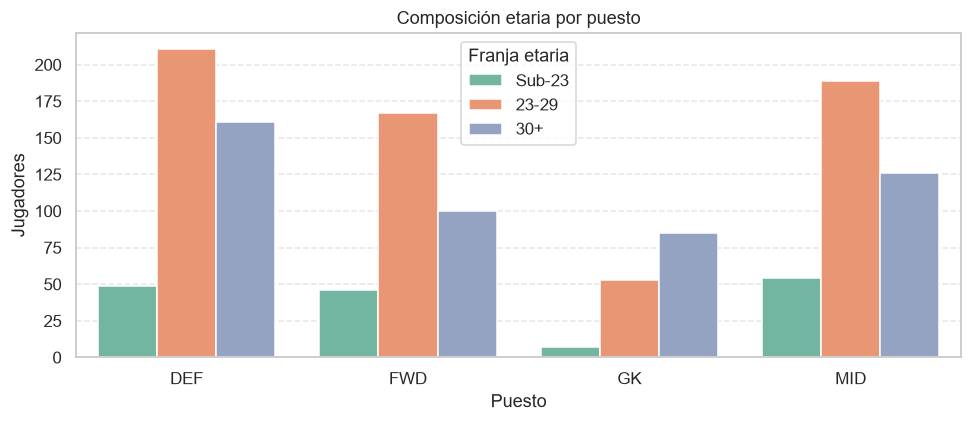

In [56]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='position', hue='franja_etaria', palette='Set2')
plt.title('Composición etaria por puesto')
plt.xlabel('Puesto'); plt.ylabel('Jugadores')
plt.legend(title='Franja etaria')
plt.grid(axis='y', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 6.3. Numérica – categórica

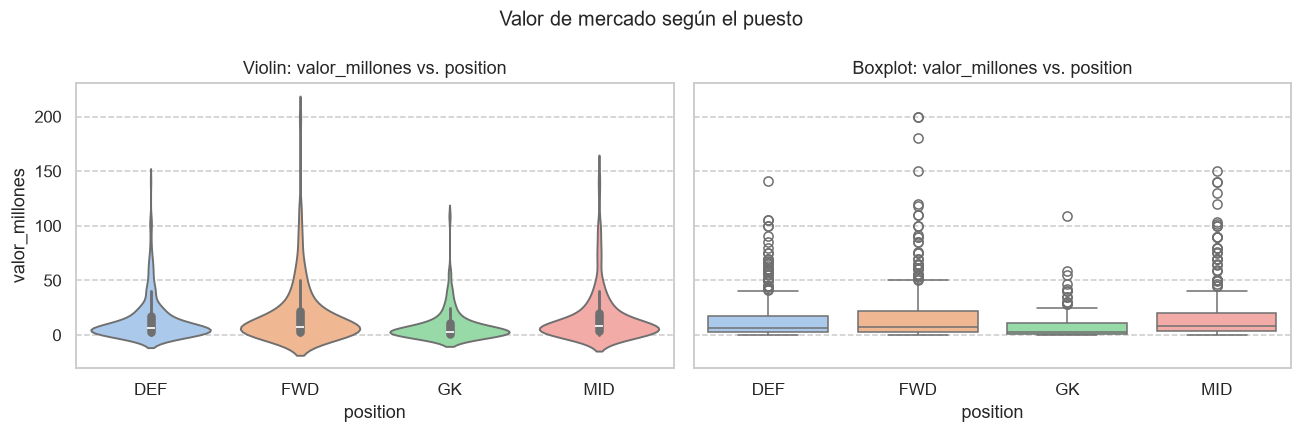

In [57]:
plot_violin_box(df, 'valor_millones', 'position',
                title='Valor de mercado según el puesto')

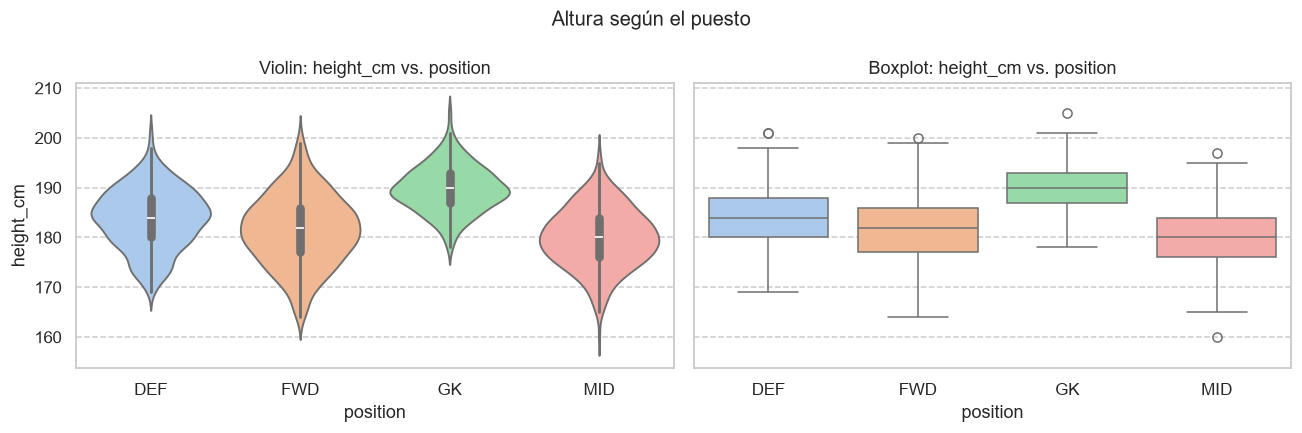

In [58]:
plot_violin_box(df, 'height_cm', 'position',
                title='Altura según el puesto')

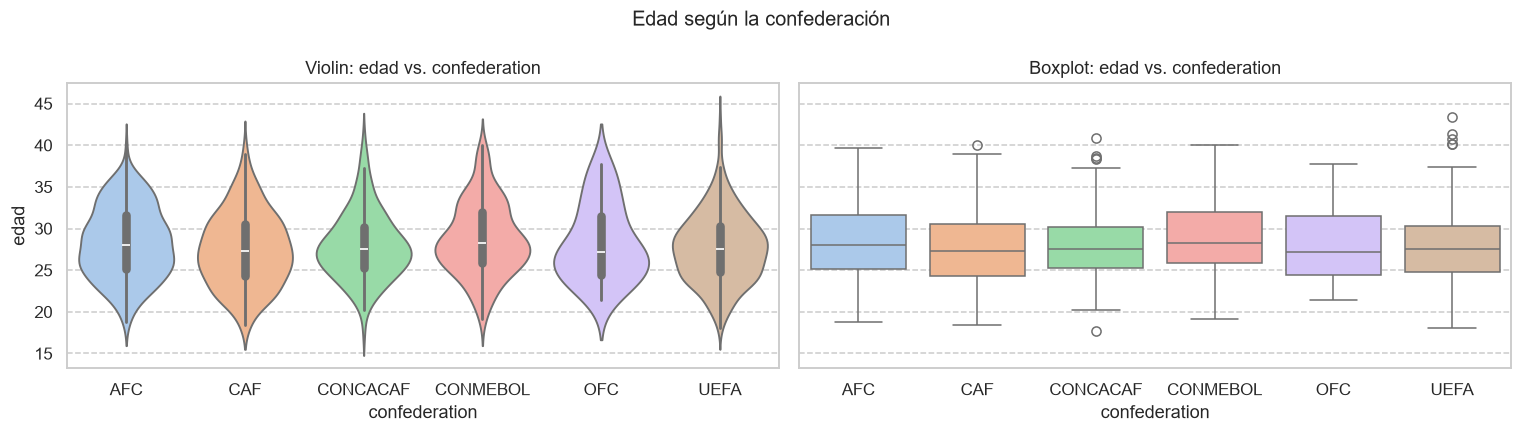

In [59]:
plot_violin_box(df, 'edad', 'confederation', figsize=(14, 4),
                title='Edad según la confederación')

In [60]:
# Estadísticos por puesto y por confederación (usando medidas robustas)
print('Valor de mercado (M€) por PUESTO:')
display(df.groupby('position', observed=True)['valor_millones']
          .agg(n='count', mediana='median', media='mean', IQR=lambda s: s.quantile(.75) - s.quantile(.25))
          .round(2).sort_values('mediana', ascending=False))

print('\nAltura (cm) por PUESTO:')
display(df.groupby('position', observed=True)['height_cm']
          .agg(n='count', mediana='median', media='mean', std='std')
          .round(2).sort_values('mediana', ascending=False))

print('\nValor de mercado (M€) por CONFEDERACIÓN:')
display(df.groupby('confederation', observed=True)['valor_millones']
          .agg(n='count', mediana='median', media='mean', maximo='max')
          .round(2).sort_values('mediana', ascending=False))

Valor de mercado (M€) por PUESTO:


,n,mediana,media,IQR
position,,,,
MID,369,7.87,16.62,16.66
FWD,313,7.69,19.68,19.00
DEF,421,6.00,13.71,14.99
GK,145,3.18,8.80,10.32



Altura (cm) por PUESTO:


,n,mediana,media,std
position,,,,
GK,145,190.00,189.78,4.60
DEF,421,184.00,183.83,6.08
FWD,313,182.00,181.44,7.03
MID,369,180.00,179.95,5.97



Valor de mercado (M€) por CONFEDERACIÓN:


,n,mediana,media,maximo
confederation,,,,
UEFA,416,15.50,27.22,200.00
CONMEBOL,156,12.88,19.83,140.83
CONCACAF,156,4.55,8.19,40.00
CAF,260,4.41,9.26,90.00
AFC,234,4.00,5.13,50.00
OFC,26,0.62,1.46,5.00


**Altura por puesto** — la relación más nítida de todo el dataset:
`GK` 190 cm > `DEF` 184 cm > `FWD` 182 cm > `MID` 180 cm. Los arqueros son en promedio **10 cm más altos**
que los mediocampistas, y además son el grupo más homogéneo (desvío 4,6 cm contra 7,0 cm de los delanteros):
la altura es un requisito casi excluyente para el puesto.

**Valor por puesto** — mediana: `MID` 7,87 M€ ≈ `FWD` 7,69 M€ > `DEF` 6,00 M€ > `GK` 3,18 M€.
Los arqueros valen aproximadamente **la mitad** que los jugadores de campo.

**Valor por confederación** — mediana: UEFA **15,50 M€**, CONMEBOL 12,88 M€, CONCACAF 4,55 M€, CAF 4,41 M€,
AFC 4,00 M€, OFC **0,62 M€**. La brecha entre UEFA y OFC es de **25 veces**.

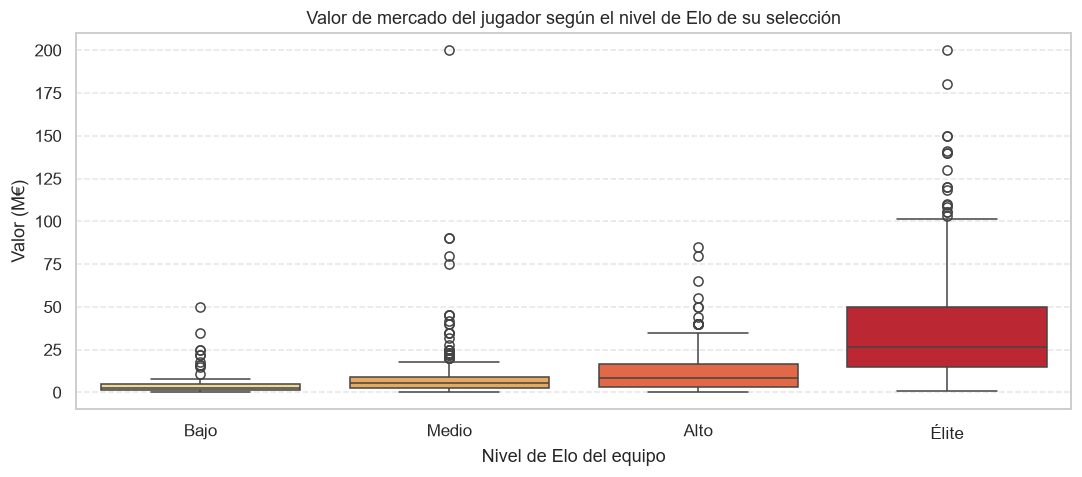

,n,mediana,media
nivel_elo,,,
Bajo,312,2.52,3.67
Medio,312,5.26,9.09
Alto,312,8.53,11.99
Élite,312,26.31,37.25


In [61]:
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=df, x='nivel_elo', y='valor_millones', hue='nivel_elo',
            palette='YlOrRd', legend=False)
plt.title('Valor de mercado del jugador según el nivel de Elo de su selección')
plt.xlabel('Nivel de Elo del equipo'); plt.ylabel('Valor (M€)')
plt.grid(axis='y', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

df.groupby('nivel_elo', observed=True)['valor_millones'].agg(
    n='count', mediana='median', media='mean').round(2)

La progresión es monótona y **acelerada**: mediana de **2,52 → 5,26 → 8,53 → 26,31 M€**.
El salto de "Alto" a "Élite" (×3,1) es mucho mayor que los anteriores (×2,1 y ×1,6).
Esto explica por qué Spearman (0,65) captaba mejor la relación que Pearson (0,57): **es monótona pero no lineal**.

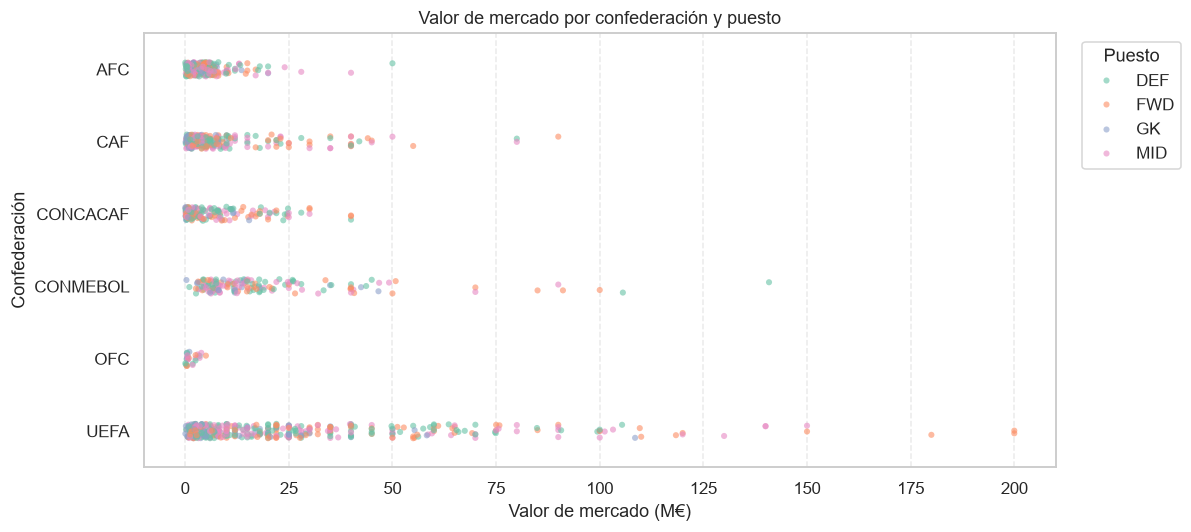

In [62]:
plt.figure(figsize=(11, 5))
sns.stripplot(data=df, x='valor_millones', y='confederation',
              hue='position', palette='Set2', alpha=0.6, size=4, jitter=True)
plt.title('Valor de mercado por confederación y puesto')
plt.xlabel('Valor de mercado (M€)'); plt.ylabel('Confederación')
plt.grid(axis='x', ls='--', alpha=0.4)
plt.legend(title='Puesto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.4. Relaciones multivariadas

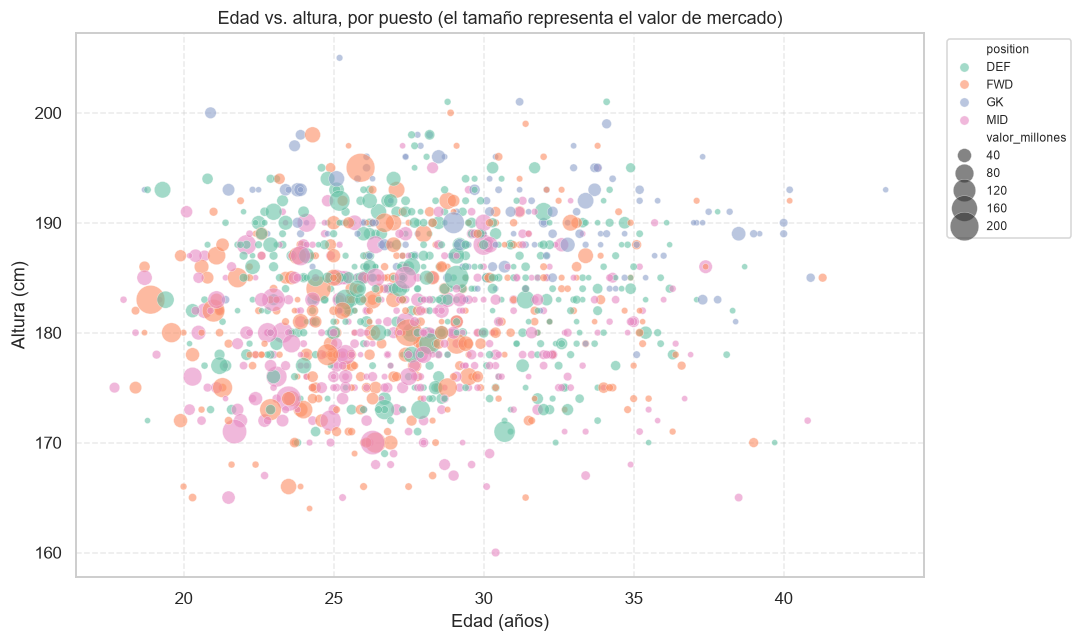

In [63]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='edad', y='height_cm', hue='position',
                size='valor_millones', sizes=(15, 350),
                palette='Set2', alpha=0.6)
plt.title('Edad vs. altura, por puesto (el tamaño representa el valor de mercado)')
plt.xlabel('Edad (años)'); plt.ylabel('Altura (cm)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

Se aprecian tres cosas a la vez: la **banda superior de arqueros**, la ausencia de relación entre edad y altura,
y que **los círculos grandes (jugadores caros) se concentran a la izquierda**, del lado de los jóvenes.

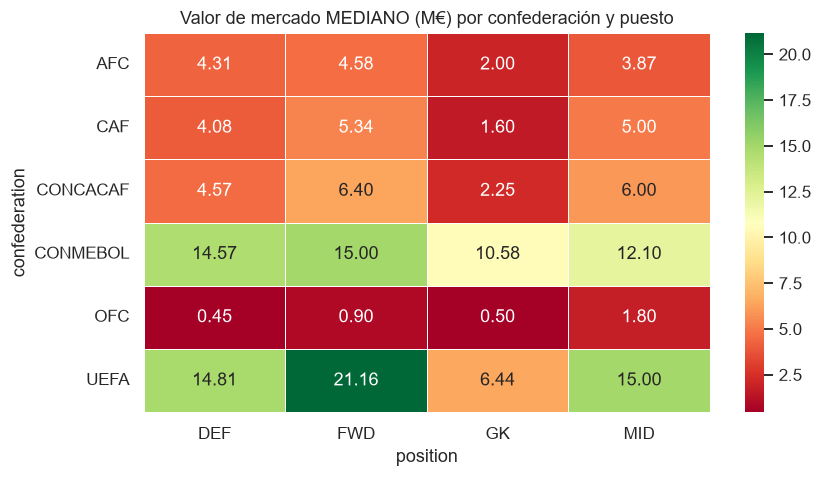

In [64]:
# Heatmap de una tercera variable numérica sobre el cruce de dos categóricas
pivot = df.pivot_table(index='confederation', columns='position',
                       values='valor_millones', aggfunc='median', observed=True)

plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=.5)
plt.title('Valor de mercado MEDIANO (M€) por confederación y puesto')
plt.tight_layout()
plt.show()

In [65]:
# Los 10 jugadores más valiosos del torneo
df.nlargest(10, 'valor_millones')[
    ['player_name', 'team_name', 'position', 'edad', 'height_cm',
     'valor_millones', 'caps', 'goals', 'minutes_played', 'goals_tournament']
].reset_index(drop=True)

,player_name,team_name,position,edad,height_cm,valor_millones,caps,goals,minutes_played,goals_tournament
0,Lamine Yamal Yamal,Spain,FWD,18.90,183.00,200.00,26,6,616,2
1,Erling Braut Haaland,Norway,FWD,25.90,195.00,200.00,51,57,450,7
2,Kylian Mbappe,France,FWD,27.50,180.00,180.00,99,58,711,10
3,Pedro Pedri,Spain,MID,23.50,174.00,150.00,42,6,638,0
4,Michael Akpovie Olise,France,FWD,24.50,184.00,150.00,18,7,668,0
5,Marcos Nicolás Senesi,Argentina,DEF,29.10,185.00,140.83,3,0,289,0
6,Pedro Joao Neves,Portugal,MID,21.70,171.00,140.00,23,4,390,1
7,Vitor Vitinha,Portugal,MID,26.30,170.00,140.00,39,0,388,0
8,Jude Victor William Bellingham,England,MID,23.00,183.00,130.00,49,7,596,7
9,Désiré Nonka-Maho Doue,France,FWD,21.00,182.00,120.00,8,2,259,1


In [66]:
# Los 10 máximos goleadores del torneo
df.nlargest(10, 'goals_tournament')[
    ['player_name', 'team_name', 'position', 'edad',
     'goals_tournament', 'assists', 'minutes_played', 'valor_millones']
].reset_index(drop=True)

,player_name,team_name,position,edad,goals_tournament,assists,minutes_played,valor_millones
0,Kylian Mbappe,France,FWD,27.50,10,4,711,180.00
1,Lionel Andrés Messi,Argentina,FWD,39.00,8,4,590,15.00
2,Erling Braut Haaland,Norway,FWD,25.90,7,0,450,200.00
3,Jude Victor William Bellingham,England,MID,23.00,7,1,596,130.00
4,Harry Edward Kane,England,FWD,32.90,6,1,534,60.00
5,Mikel Oyarzabal,Spain,FWD,29.10,5,1,394,35.00
6,Masour Ousmane Dembele,France,FWD,29.10,5,2,363,100.00
7,Julián Andrés Quinones,Mexico,FWD,29.20,4,1,221,14.00
8,José Vinicius,Brazil,FWD,25.90,4,1,441,14.81
9,Bradley Jean-Manuel Essolisa Barcola,France,FWD,23.80,4,1,283,69.22


---
## 7. Conclusiones

### Sobre la calidad de los datos

- El DataFrame de análisis (1248 × 26) está **completo**: sin nulos, sin duplicados y perfectamente
  balanceado (48 selecciones × 26 jugadores).
- En el archivo original `player_stats.csv` sí había problemas, y conviene distinguir dos casos muy diferentes:
  columnas **100 % vacías** (`shots`, `shots_on_target`, `average_rating`), que directamente no sirven; y
  **nulos estructurales** (`saves`, `clean_sheets`, `goals_conceded`), que solo aplican a los 145 arqueros.
  Imputar estos últimos con 0 o con la media sería un error conceptual.

### Sobre las distribuciones (análisis univariado)

- Hay **dos familias claras de variables numéricas**:
  - **Simétricas y casi normales:** `edad` (asimetría +0,33) y `height_cm` (−0,09). Media ≈ mediana ≈ moda.
    Para describirlas, media y desvío estándar son perfectamente adecuados.
  - **Fuertemente asimétricas a derecha:** `valor_millones` (+3,26 con curtosis exceso **+14,2**),
    `caps` (+1,61) y `goals` (+5,98). Acá la media **engaña**.
- El caso del **valor de mercado** es el más ilustrativo de toda la teoría de la clase:
  media 15,50 M€ contra mediana 6,57 M€; desvío estándar 23,45 contra MAD 5,07; 113 outliers (9,1 %) por el
  criterio de 1,5·IQR; y un IQR que representa apenas el **7,7 % del rango total** (muy por debajo del umbral
  del 20 %, o sea datos concentrados con una cola larguísima).
  **El 10 % de los jugadores más caros concentra el 46,8 % del valor total de todos los planteles.**
  → Para esta variable hay que usar **estadística robusta: mediana + IQR**.
  Una transformación `log10` reduce la asimetría de +3,26 a −0,38, lo que sugiere un comportamiento **log-normal**.

### Sobre las variables categóricas

- La **entropía de Shannon** ordena bien las variables por cuánta información aportan:
  `group_letter` alcanza la **entropía máxima** (H = H_máx = 3,585 bits, normalizada = 1,000) porque el torneo
  reparte exactamente 104 jugadores por grupo → es la variable **menos informativa**.
  `confederation` es la más desbalanceada (normalizada 0,897): UEFA 33,3 % vs. OFC 2,1 %.
- La composición por puesto es casi idéntica en todas las confederaciones, con un **11,5 % de arqueros exacto**
  en todas: no es un patrón deportivo sino una **restricción del reglamento** (3 arqueros de 26 convocados).

### Sobre las relaciones entre variables (análisis bivariado)

| Relación | Coeficiente | Lectura |
|---|---|---|
| `elo_rating` ~ `fifa_ranking` | −0,94 | **Redundancia**: son dos formas de medir lo mismo (multicolinealidad) |
| `height_cm` ~ `position` | — | La más fuerte del dataset: GK 190 > DEF 184 > FWD 182 > MID 180 cm |
| `valor` ~ `nivel_elo` | Spearman 0,65 | Progresión monótona **acelerada**: 2,5 → 5,3 → 8,5 → 26,3 M€ |
| `edad` ~ `caps` | 0,61 | Esperable: más edad, más partidos acumulados |
| `valor` ~ `minutes_played` | 0,43 | Los jugadores caros efectivamente juegan más |
| `edad` ~ `valor` | −0,22 | El mercado paga **proyección**, no trayectoria |
| `caps` ~ `valor` | ≈ 0,00 | **La experiencia internacional NO explica el valor de mercado** |

- **Comparar Pearson, Spearman y Kendall no fue un ejercicio decorativo:** en `height_cm ~ goals`,
  Pearson da −0,06 (parecería no haber relación) mientras Spearman da −0,20 y detecta la relación
  **monótona no lineal** real (los más altos meten menos goles). Es el caso exacto que la teoría señala
  como la limitación de Pearson.
- Inversamente, cuando **los tres métodos coinciden** en ~0 (como en `caps ~ valor`), la ausencia de relación
  se puede afirmar con confianza.

### Advertencia metodológica

`elo_rating` y `fifa_ranking_pre_tournament` son atributos del **equipo**, repetidos en los 26 jugadores de cada
selección. Las correlaciones que los involucran están calculadas sobre 1248 filas, pero la cantidad real de
observaciones independientes es **48**. Los coeficientes son válidos como descripción, pero no habría que
usarlos para inferencia sin corregir esa dependencia. Visualmente el problema se ve en el scatterplot de la
sección 6.1: los puntos se apilan en columnas verticales.

---

### Verificación de la consigna

| Requisito | Dónde se cumple |
|---|---|
| Estadística descriptiva | Secciones 4.1 a 4.7 (tendencia central, dispersión, cuartiles/IQR, forma, robusta, `describe()`) |
| Tipos de variables | Sección 3 (clasificación y asignación de `dtype`, incluidas ordinales con `CategoricalDtype`) |
| Relaciones entre variables | Sección 6 (num–num, cat–cat, num–cat y multivariado) |
| Al menos 3 gráficos | **Más de 25 gráficos** a lo largo de toda la notebook |
| Código ejecutado con salidas | Todas las celdas se ejecutaron de arriba a abajo |

In [67]:
print(f'Filas analizadas   : {df.shape[0]}')
print(f'Columnas analizadas: {df.shape[1]}')
print(f'Numéricas          : {len(numericas)}')
print(f'Categóricas        : {len(cat_nominales) + len(cat_ordinales)}')
print('\nEDA finalizado.')

Filas analizadas   : 1248
Columnas analizadas: 26
Numéricas          : 14
Categóricas        : 8

EDA finalizado.
